## 1. Importar librerías necesarias

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f'GPU disponible: {physical_devices[0].name}')
else:
    print('Usando CPU')

I0000 00:00:1777774530.913940  289710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777774530.916179  289710 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777774531.200157  289710 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777774532.190151  289710 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Usando CPU


E0000 00:00:1777774533.268111  289710 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777774533.268465  290112 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777774533.291141  289710 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. GANs

Una GAN consiste en dos redes neuronales que compiten entre sí:

- Generador (G): transforma ruido aleatorio en datos sintéticos.
- Discriminador (D): estima si una muestra es real o generada.

En este cuaderno las arquitecturas de los ejemplos 1 y 2 son convolucionales tanto para el generador como para el discriminador.

---

# Ejemplo 1: GAN convolucional en MNIST

Usamos un generador con convoluciones transpuestas y un discriminador convolucional.

In [2]:
(x_train, _), _ = keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

batch_size = 128
latent_dim = 100
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(buffer_size=60000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print(f'Total de imágenes de entrenamiento: {len(x_train)}')
print(f'Forma de las imágenes: {x_train.shape}')
print(f'Tamaño de batch: {batch_size}')

Total de imágenes de entrenamiento: 60000
Forma de las imágenes: (60000, 28, 28, 1)
Tamaño de batch: 128


## Generador convolucional

Partimos de un vector latente, lo proyectamos a un mapa 7x7 y luego lo ampliamos hasta 28x28 con convoluciones transpuestas.

In [3]:
def build_generator(latent_dim=100):
    model = keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.Reshape((7, 7, 256)),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2D(1, kernel_size=3, padding='same', activation='tanh')
    ], name='generator')
    return model

generator = build_generator(latent_dim)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,912,129 (7.29 MB)

 Trainable params: 1,911,233 (7.29 MB)

 Non-trainable params: 896 (3.50 KB)

## Discriminador convolucional

La imagen de entrada se reduce progresivamente mediante convoluciones con stride antes de clasificarla como real o falsa.

In [4]:
def build_discriminator():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(256, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ], name='discriminator')
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,929 (2.52 MB)

 Trainable params: 660,929 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

## Configuración de entrenamiento

In [5]:
cross_entropy = keras.losses.BinaryCrossentropy()
lr = 0.0002
optimizer_G = keras.optimizers.Adam(lr, beta_1=0.5)
optimizer_D = keras.optimizers.Adam(lr, beta_1=0.5)
num_epochs = 50
sample_interval = 5
fixed_noise = tf.random.normal([64, latent_dim])
d_losses = []
g_losses = []

print('Configuración completada.')

Configuración completada.


## Entrenamiento de la GAN

E0000 00:00:1777774535.005888  289710 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/discriminator_3/leaky_re_lu_3_1/LeakyRelu/LeakyReluGrad' exist for missing node 'discriminator_3/conv2d_1_1/BiasAdd'.
E0000 00:00:1777774595.204303  289710 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/discriminator_5/leaky_re_lu_5_1/LeakyRelu/LeakyReluGrad' exist for missing node 'discriminator_5/conv2d_3_1/BiasAdd'.


Epoch [1/50] | D Loss: 1.3618 | G Loss: 0.7411
Epoch [2/50] | D Loss: 1.2842 | G Loss: 0.8496
Epoch [3/50] | D Loss: 1.3128 | G Loss: 0.8025
Epoch [4/50] | D Loss: 1.2998 | G Loss: 0.8223
Epoch [5/50] | D Loss: 1.2964 | G Loss: 0.8327


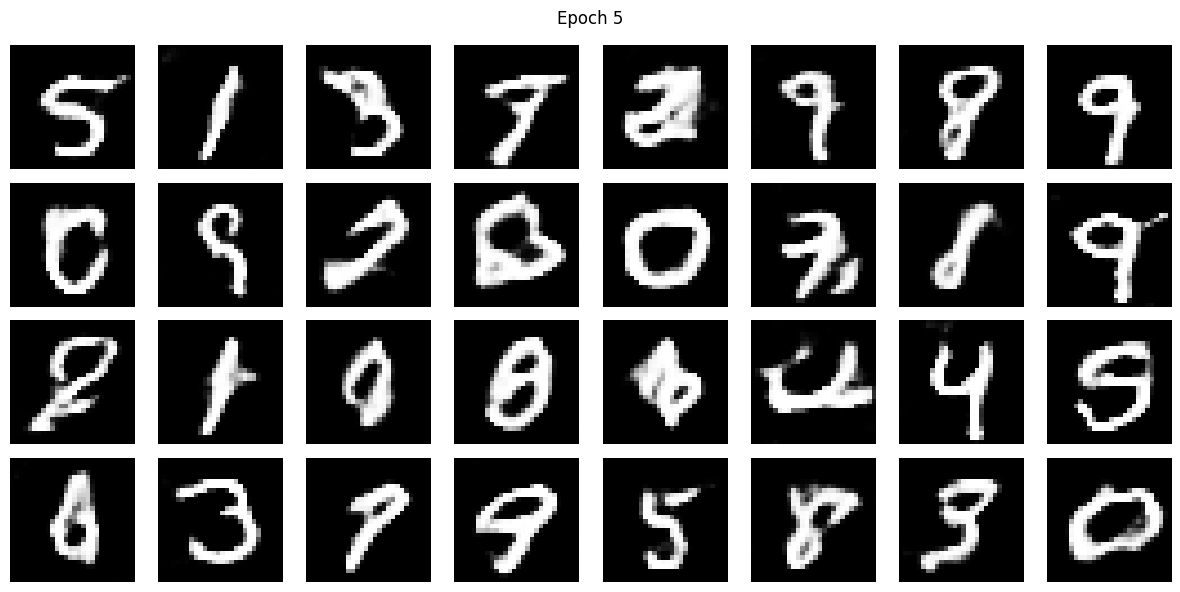

Epoch [6/50] | D Loss: 1.2942 | G Loss: 0.8365
Epoch [7/50] | D Loss: 1.2963 | G Loss: 0.8293
Epoch [8/50] | D Loss: 1.2997 | G Loss: 0.8280
Epoch [9/50] | D Loss: 1.3056 | G Loss: 0.8263
Epoch [10/50] | D Loss: 1.3049 | G Loss: 0.8175


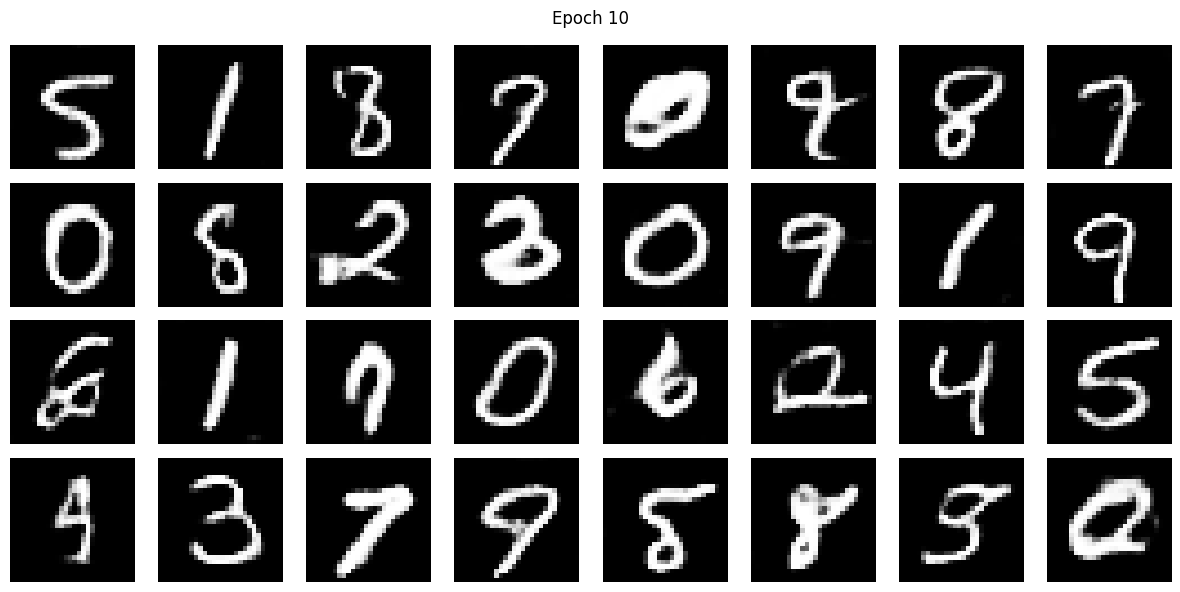

Epoch [11/50] | D Loss: 1.3097 | G Loss: 0.8144
Epoch [12/50] | D Loss: 1.3103 | G Loss: 0.8096
Epoch [13/50] | D Loss: 1.3118 | G Loss: 0.8134
Epoch [14/50] | D Loss: 1.3135 | G Loss: 0.8097
Epoch [15/50] | D Loss: 1.3152 | G Loss: 0.8122


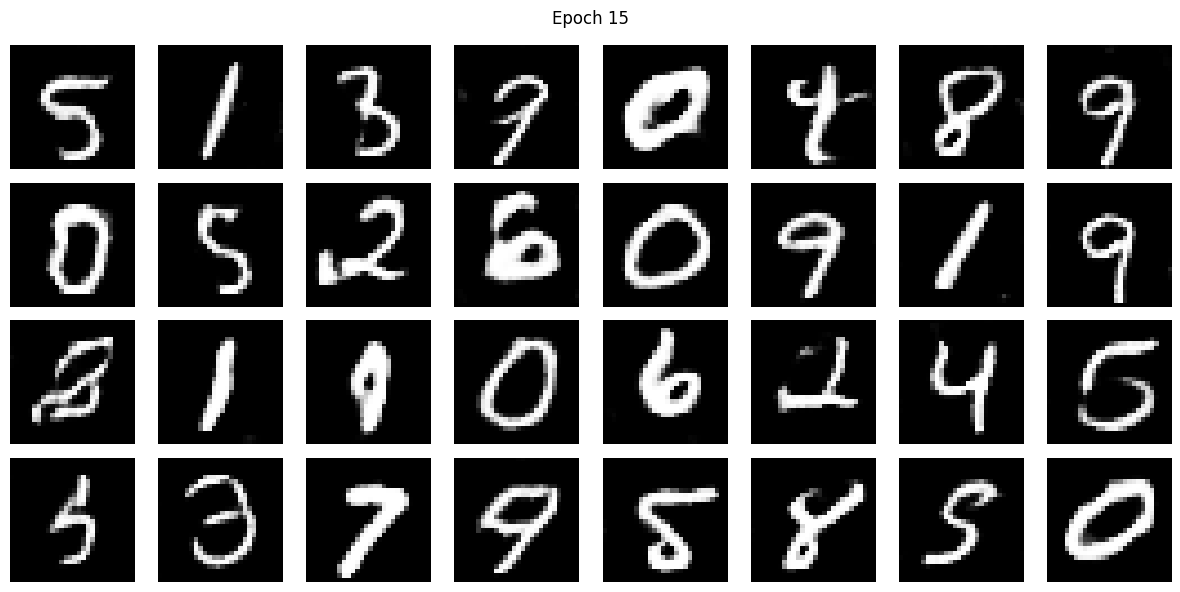

Epoch [16/50] | D Loss: 1.3151 | G Loss: 0.8068
Epoch [17/50] | D Loss: 1.3166 | G Loss: 0.8059
Epoch [18/50] | D Loss: 1.3151 | G Loss: 0.8042
Epoch [19/50] | D Loss: 1.3145 | G Loss: 0.8058
Epoch [20/50] | D Loss: 1.3181 | G Loss: 0.8048


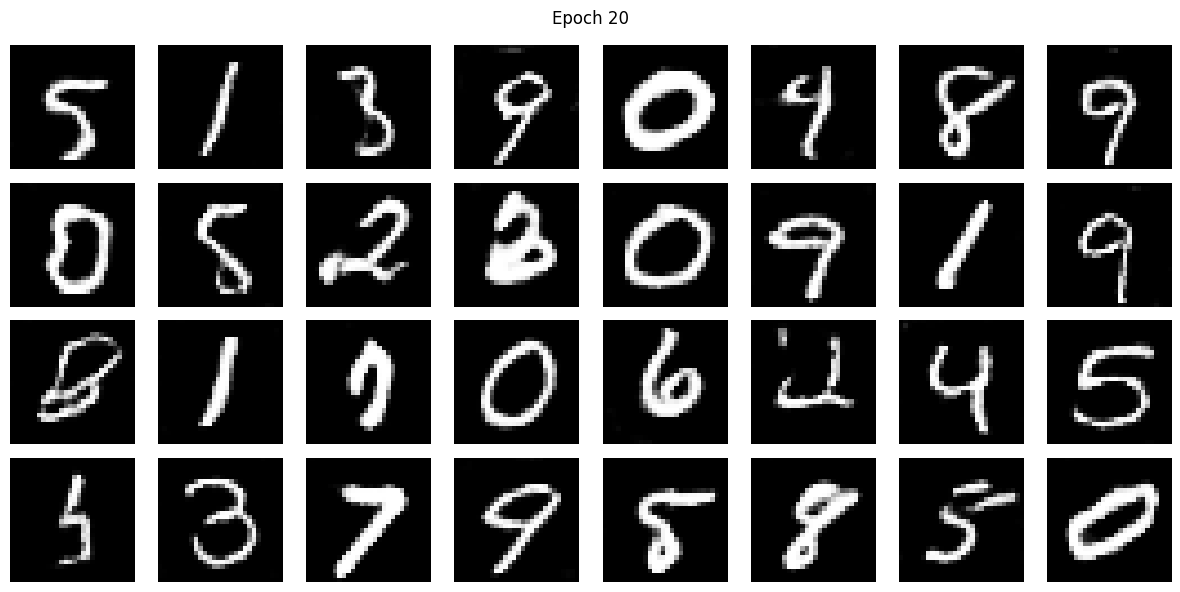

Epoch [21/50] | D Loss: 1.3162 | G Loss: 0.8064
Epoch [22/50] | D Loss: 1.3166 | G Loss: 0.8058
Epoch [23/50] | D Loss: 1.3161 | G Loss: 0.8077
Epoch [24/50] | D Loss: 1.3164 | G Loss: 0.8038
Epoch [25/50] | D Loss: 1.3144 | G Loss: 0.8047


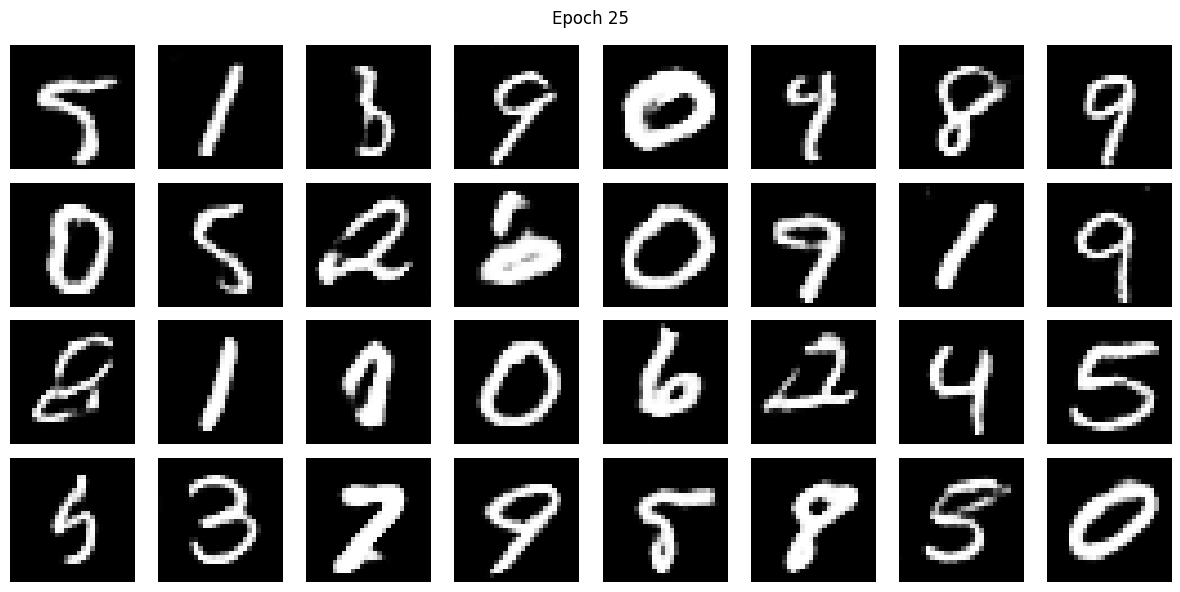

Epoch [26/50] | D Loss: 1.3148 | G Loss: 0.8067
Epoch [27/50] | D Loss: 1.3132 | G Loss: 0.8101
Epoch [28/50] | D Loss: 1.3134 | G Loss: 0.8061
Epoch [29/50] | D Loss: 1.3114 | G Loss: 0.8112
Epoch [30/50] | D Loss: 1.3118 | G Loss: 0.8143


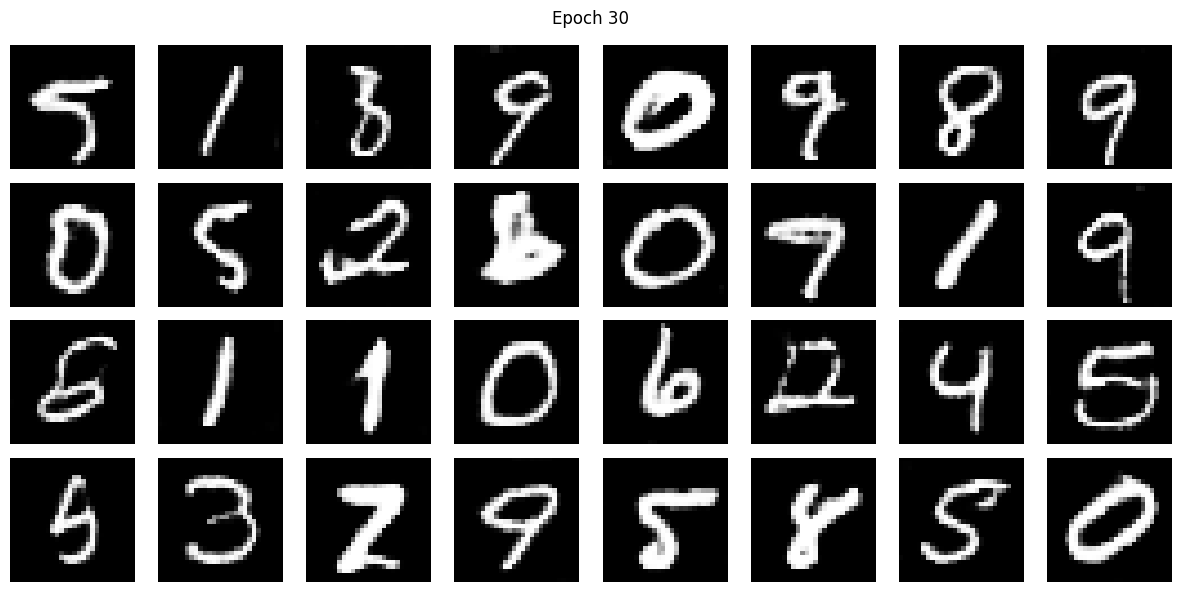

Epoch [31/50] | D Loss: 1.3114 | G Loss: 0.8136
Epoch [32/50] | D Loss: 1.3096 | G Loss: 0.8108
Epoch [33/50] | D Loss: 1.3084 | G Loss: 0.8169
Epoch [34/50] | D Loss: 1.3111 | G Loss: 0.8146
Epoch [35/50] | D Loss: 1.3086 | G Loss: 0.8171


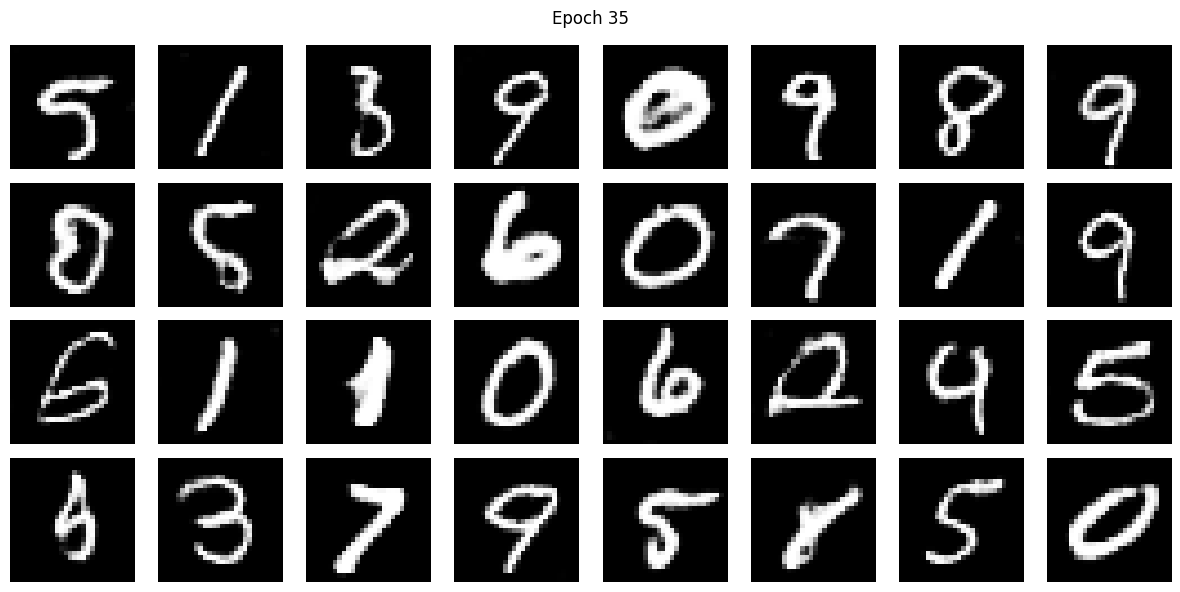

Epoch [36/50] | D Loss: 1.3118 | G Loss: 0.8138
Epoch [37/50] | D Loss: 1.3092 | G Loss: 0.8146
Epoch [38/50] | D Loss: 1.3078 | G Loss: 0.8174
Epoch [39/50] | D Loss: 1.3070 | G Loss: 0.8172
Epoch [40/50] | D Loss: 1.3090 | G Loss: 0.8199


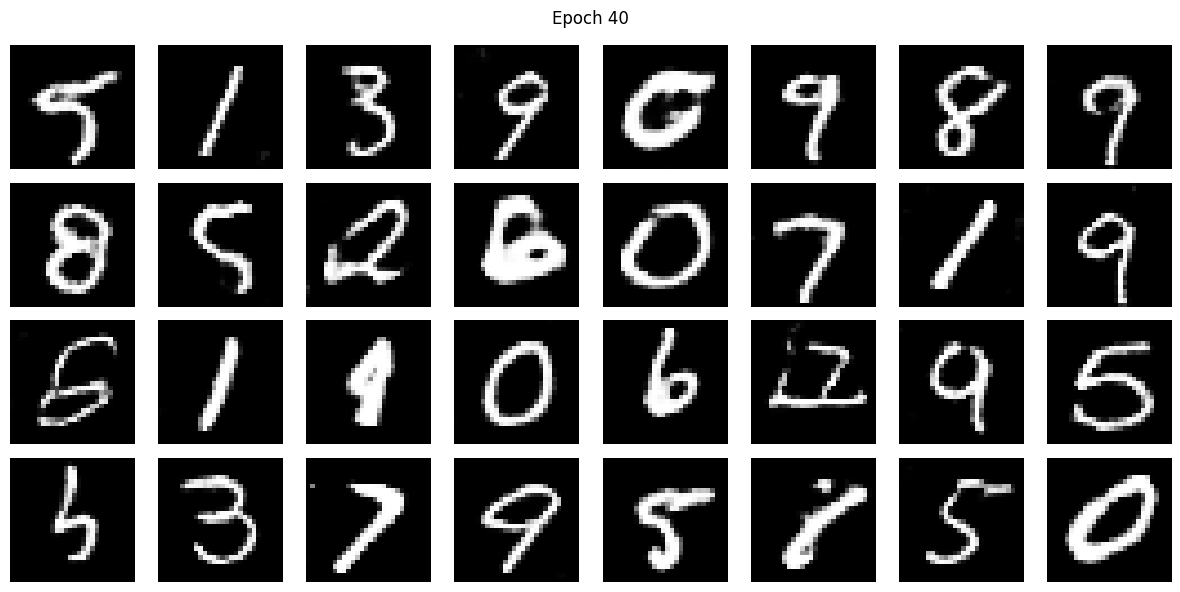

Epoch [41/50] | D Loss: 1.3077 | G Loss: 0.8168
Epoch [42/50] | D Loss: 1.3098 | G Loss: 0.8182
Epoch [43/50] | D Loss: 1.3048 | G Loss: 0.8220
Epoch [44/50] | D Loss: 1.3051 | G Loss: 0.8235
Epoch [45/50] | D Loss: 1.3057 | G Loss: 0.8206


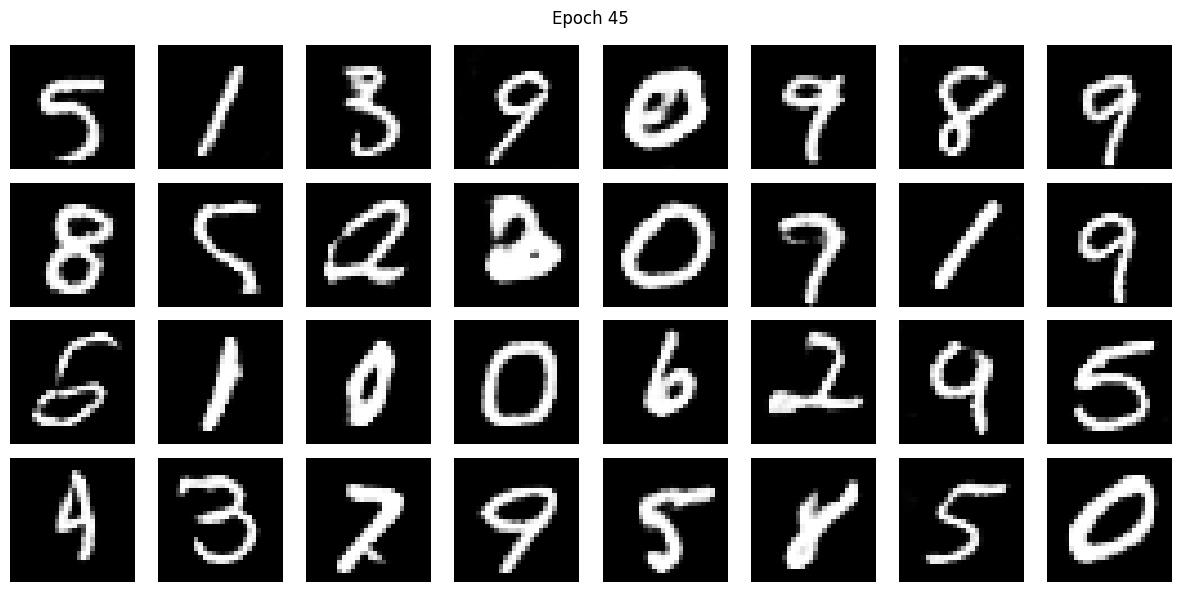

Epoch [46/50] | D Loss: 1.3057 | G Loss: 0.8203
Epoch [47/50] | D Loss: 1.3068 | G Loss: 0.8237
Epoch [48/50] | D Loss: 1.3065 | G Loss: 0.8213
Epoch [49/50] | D Loss: 1.3049 | G Loss: 0.8186
Epoch [50/50] | D Loss: 1.3037 | G Loss: 0.8235


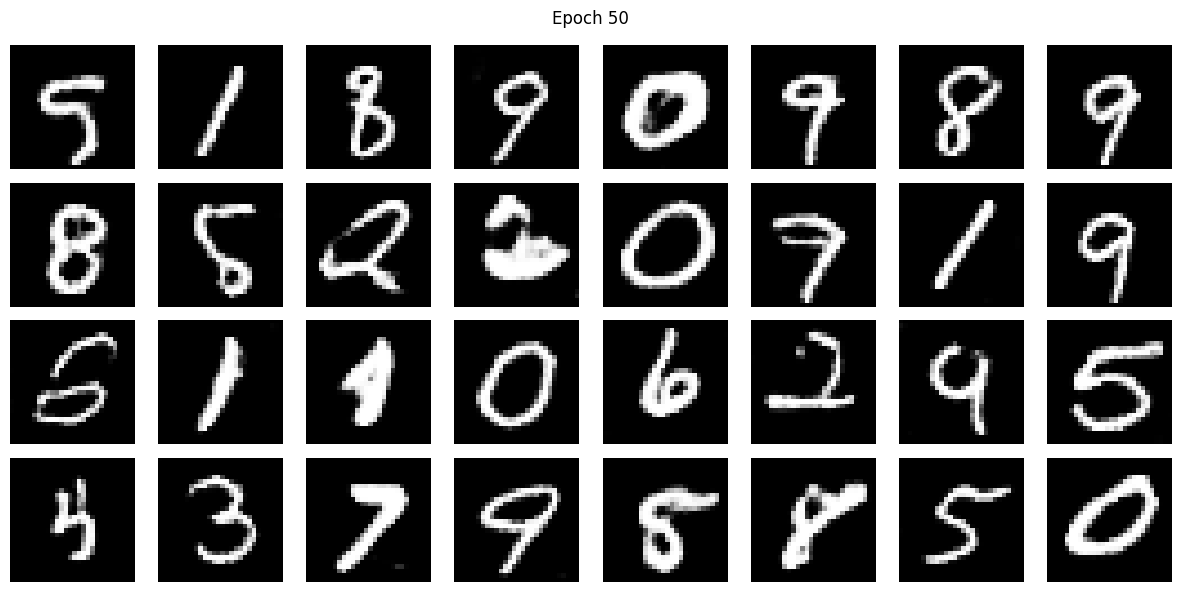

In [6]:
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    real_labels = tf.ones((batch_size, 1))
    fake_labels = tf.zeros((batch_size, 1))

    with tf.GradientTape() as tape_d:
        real_validity = discriminator(real_images, training=True)
        d_loss_real = cross_entropy(real_labels, real_validity)

        z = tf.random.normal([batch_size, latent_dim])
        fake_images = generator(z, training=True)
        fake_validity = discriminator(fake_images, training=True)
        d_loss_fake = cross_entropy(fake_labels, fake_validity)
        d_loss = d_loss_real + d_loss_fake

    grads_d = tape_d.gradient(d_loss, discriminator.trainable_variables)
    optimizer_D.apply_gradients(zip(grads_d, discriminator.trainable_variables))

    with tf.GradientTape() as tape_g:
        z = tf.random.normal([batch_size, latent_dim])
        gen_images = generator(z, training=True)
        validity = discriminator(gen_images, training=True)
        g_loss = cross_entropy(real_labels, validity)

    grads_g = tape_g.gradient(g_loss, generator.trainable_variables)
    optimizer_G.apply_gradients(zip(grads_g, generator.trainable_variables))

    return d_loss, g_loss

def train_gan():
    for epoch in range(num_epochs):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0
        num_batches = 0

        for real_imgs in train_dataset:
            d_loss, g_loss = train_step(real_imgs)
            epoch_d_loss += d_loss
            epoch_g_loss += g_loss
            num_batches += 1

        avg_d_loss = epoch_d_loss / num_batches
        avg_g_loss = epoch_g_loss / num_batches
        d_losses.append(float(avg_d_loss))
        g_losses.append(float(avg_g_loss))
        print(f'Epoch [{epoch + 1}/{num_epochs}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}')

        if (epoch + 1) % sample_interval == 0:
            samples = generator(fixed_noise, training=False).numpy()
            fig, axes = plt.subplots(4, 8, figsize=(12, 6))
            for idx, ax in enumerate(axes.flat):
                if idx < 32:
                    ax.imshow(samples[idx, :, :, 0], cmap='gray')
                    ax.axis('off')
            plt.suptitle(f'Epoch {epoch + 1}')
            plt.tight_layout()
            plt.show()

train_gan()

## Evolución de la función de coste

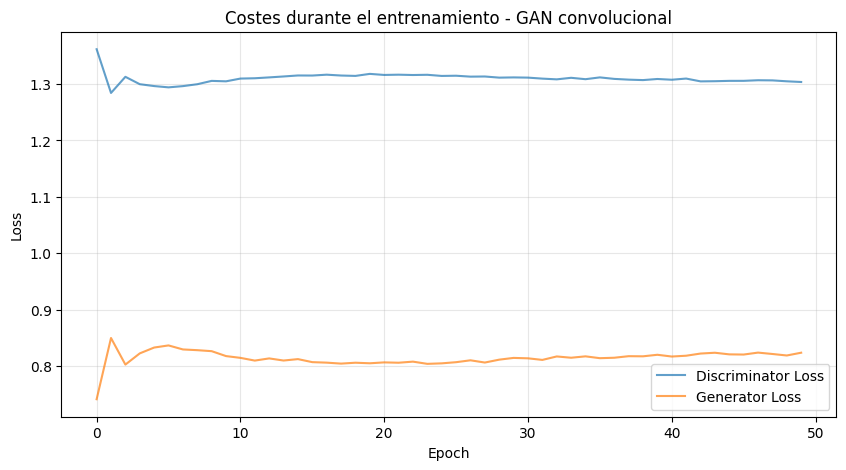

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss', alpha=0.7)
plt.plot(g_losses, label='Generator Loss', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Costes durante el entrenamiento - GAN convolucional')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Muestras generadas

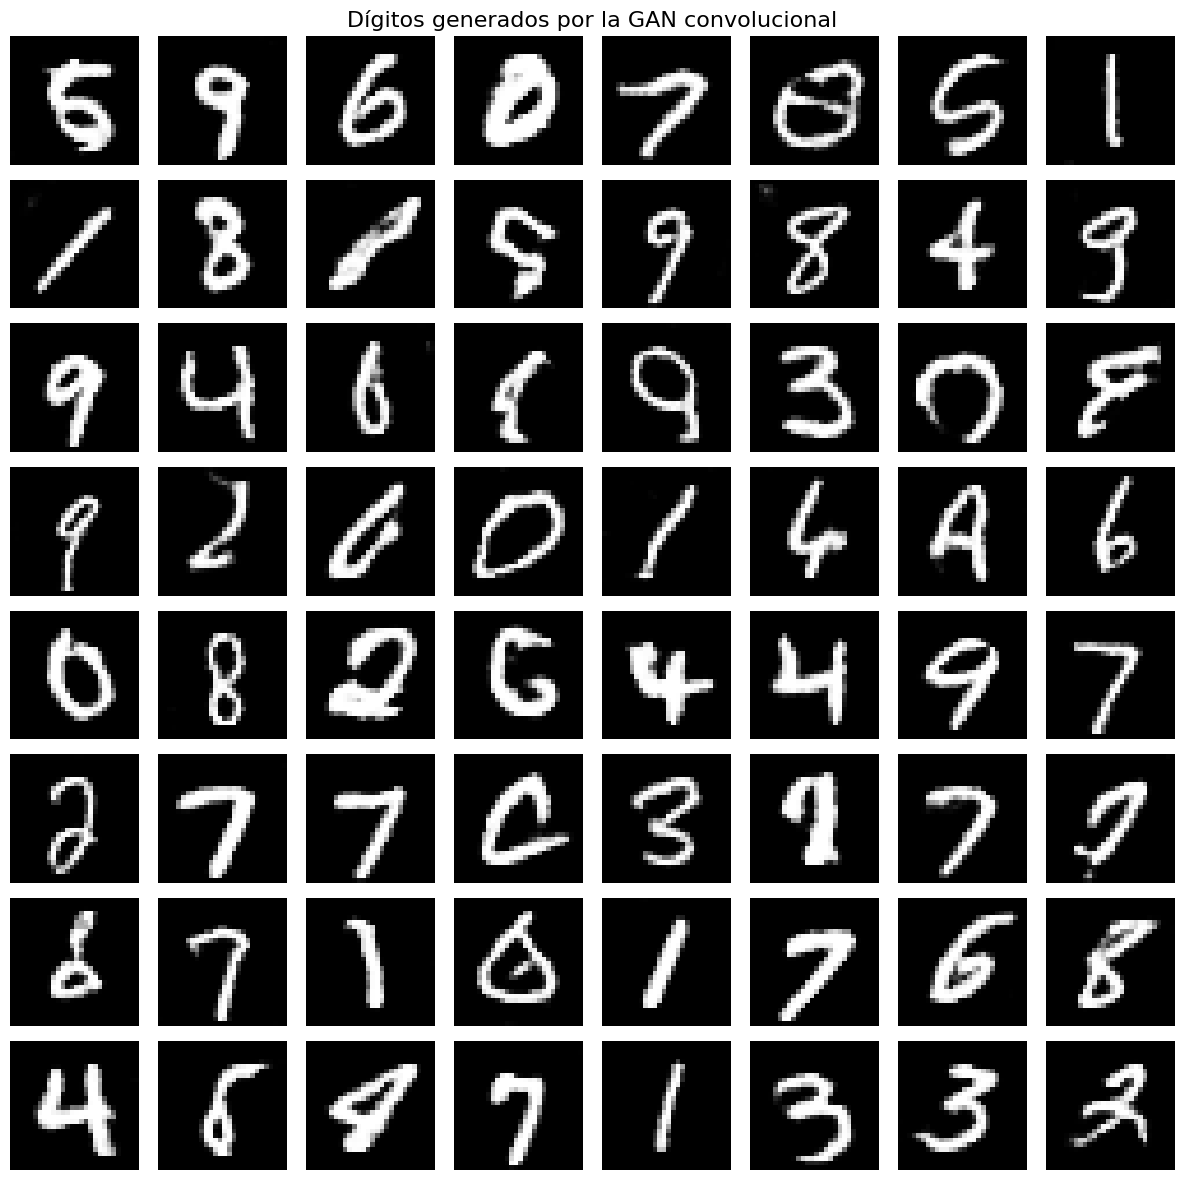

In [8]:
z = tf.random.normal([64, latent_dim])
generated_imgs = generator(z, training=False).numpy()

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for idx, ax in enumerate(axes.flat):
    ax.imshow(generated_imgs[idx, :, :, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('Dígitos generados por la GAN convolucional', fontsize=16)
plt.tight_layout()
plt.show()

---

# Ejemplo 2: Conditional GAN convolucional en Fashion-MNIST

La información de clase se integra espacialmente para que el discriminador y el generador trabajen con tensores 2D en lugar de bloques densos puros.

In [9]:
(x_fashion, y_fashion), _ = keras.datasets.fashion_mnist.load_data()
x_fashion = (x_fashion.astype('float32') - 127.5) / 127.5
x_fashion = np.expand_dims(x_fashion, axis=-1)
fashion_dataset = tf.data.Dataset.from_tensor_slices((x_fashion, y_fashion))
fashion_dataset = fashion_dataset.shuffle(buffer_size=60000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
num_classes = 10
print(f'Número de clases: {num_classes}')

Número de clases: 10


## Generador condicional convolucional

La etiqueta se embebe y se concatena con el vector latente antes de proyectarse a un mapa espacial.

In [10]:
def build_conditional_generator(latent_dim=100, num_classes=10, embedding_dim=50):
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(num_classes, embedding_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    gen_input = layers.Concatenate()([noise_input, label_embedding])

    x = layers.Dense(7 * 7 * 256, use_bias=False)(gen_input)
    x = layers.Reshape((7, 7, 256))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    img_output = layers.Conv2D(1, kernel_size=3, padding='same', activation='tanh')(x)

    return keras.Model([noise_input, label_input], img_output, name='conditional_generator')

cond_generator = build_conditional_generator(latent_dim, num_classes)
cond_generator.summary()

Model: "conditional_generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        500 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12544)     │  1,881,600 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 7, 7, 256) │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 256) │      1,024 │ reshape_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 7, 7, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 14, 14,    │    524,288 │ leaky_re_lu_6[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 28, 28,    │    131,072 │ leaky_re_lu_7[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28, 1) │        577 │ leaky_re_lu_8[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,539,829 (9.69 MB)

 Trainable params: 2,538,933 (9.69 MB)

 Non-trainable params: 896 (3.50 KB)

## Discriminador condicional convolucional

La etiqueta se convierte en un mapa 28x28 y se concatena como un canal adicional junto a la imagen.

In [11]:
def build_conditional_discriminator(num_classes=10):
    img_input = layers.Input(shape=(28, 28, 1))
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(num_classes, 28 * 28)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    label_map = layers.Reshape((28, 28, 1))(label_embedding)

    x = layers.Concatenate(axis=-1)([img_input, label_map])
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(256, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    validity = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model([img_input, label_input], validity, name='conditional_discriminator')

cond_discriminator = build_conditional_discriminator(num_classes)
cond_discriminator.summary()

Model: "conditional_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 784)    │      7,840 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 784)       │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 28, 28, 1) │          0 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ input_layer_4[0]… │
│ (Concatenate)       │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │      2,112 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 14, 14,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 14, 14,    │          0 │ leaky_re_lu_9[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 128) │    131,200 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 7, 7, 128) │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 4, 4, 256) │    524,544 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 4, 4, 256) │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 4, 4, 256) │          0 │ leaky_re_lu_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4096)      │          0 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │      4,097 │ flatten_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 669,793 (2.56 MB)

 Trainable params: 669,793 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

## Configuración de la cGAN

In [12]:
optimizer_cG = keras.optimizers.Adam(lr, beta_1=0.5)
optimizer_cD = keras.optimizers.Adam(lr, beta_1=0.5)
num_epochs_cgan = 50
cd_losses = []
cg_losses = []
fixed_labels = tf.constant([[i % num_classes] for i in range(100)], dtype=tf.int32)
fixed_noise_cgan = tf.random.normal([100, latent_dim])

print('Configuración completada para cGAN.')

Configuración completada para cGAN.


## Entrenamiento de la cGAN

E0000 00:00:1777777612.479977  289710 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/conditional_discriminator_5/leaky_re_lu_9_1/LeakyRelu/LeakyReluGrad' exist for missing node 'conditional_discriminator_5/conv2d_5_1/BiasAdd'.
E0000 00:00:1777777676.609612  289710 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/conditional_discriminator_5/leaky_re_lu_11_1/LeakyRelu/LeakyReluGrad' exist for missing node 'conditional_discriminator_5/conv2d_7_1/BiasAdd'.


Epoch [1/50] | D Loss: 1.3108 | G Loss: 0.8352
Epoch [2/50] | D Loss: 1.2662 | G Loss: 0.8886
Epoch [3/50] | D Loss: 1.2711 | G Loss: 0.8840
Epoch [4/50] | D Loss: 1.3114 | G Loss: 0.8163
Epoch [5/50] | D Loss: 1.3260 | G Loss: 0.7913


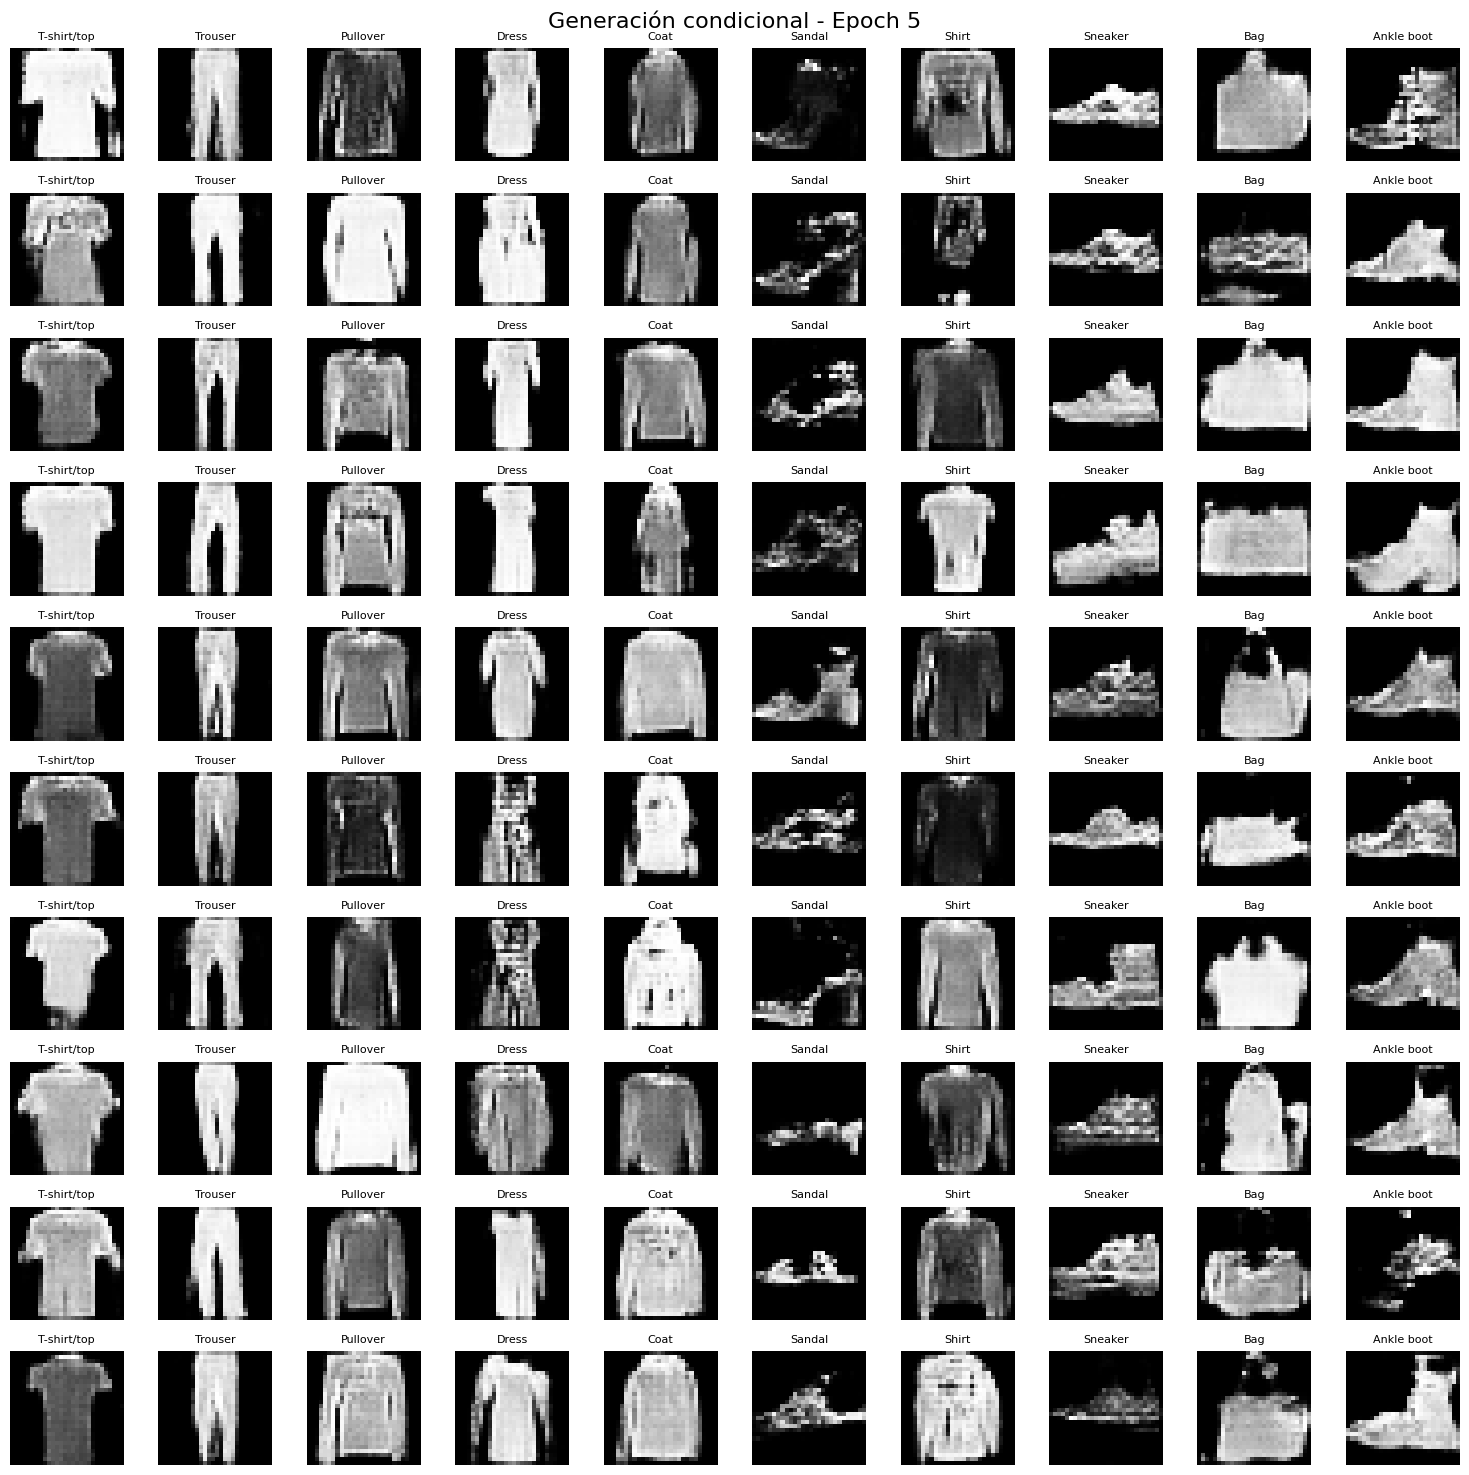

Epoch [6/50] | D Loss: 1.3348 | G Loss: 0.7803
Epoch [7/50] | D Loss: 1.3379 | G Loss: 0.7745
Epoch [8/50] | D Loss: 1.3394 | G Loss: 0.7740
Epoch [9/50] | D Loss: 1.3381 | G Loss: 0.7674
Epoch [10/50] | D Loss: 1.3436 | G Loss: 0.7672


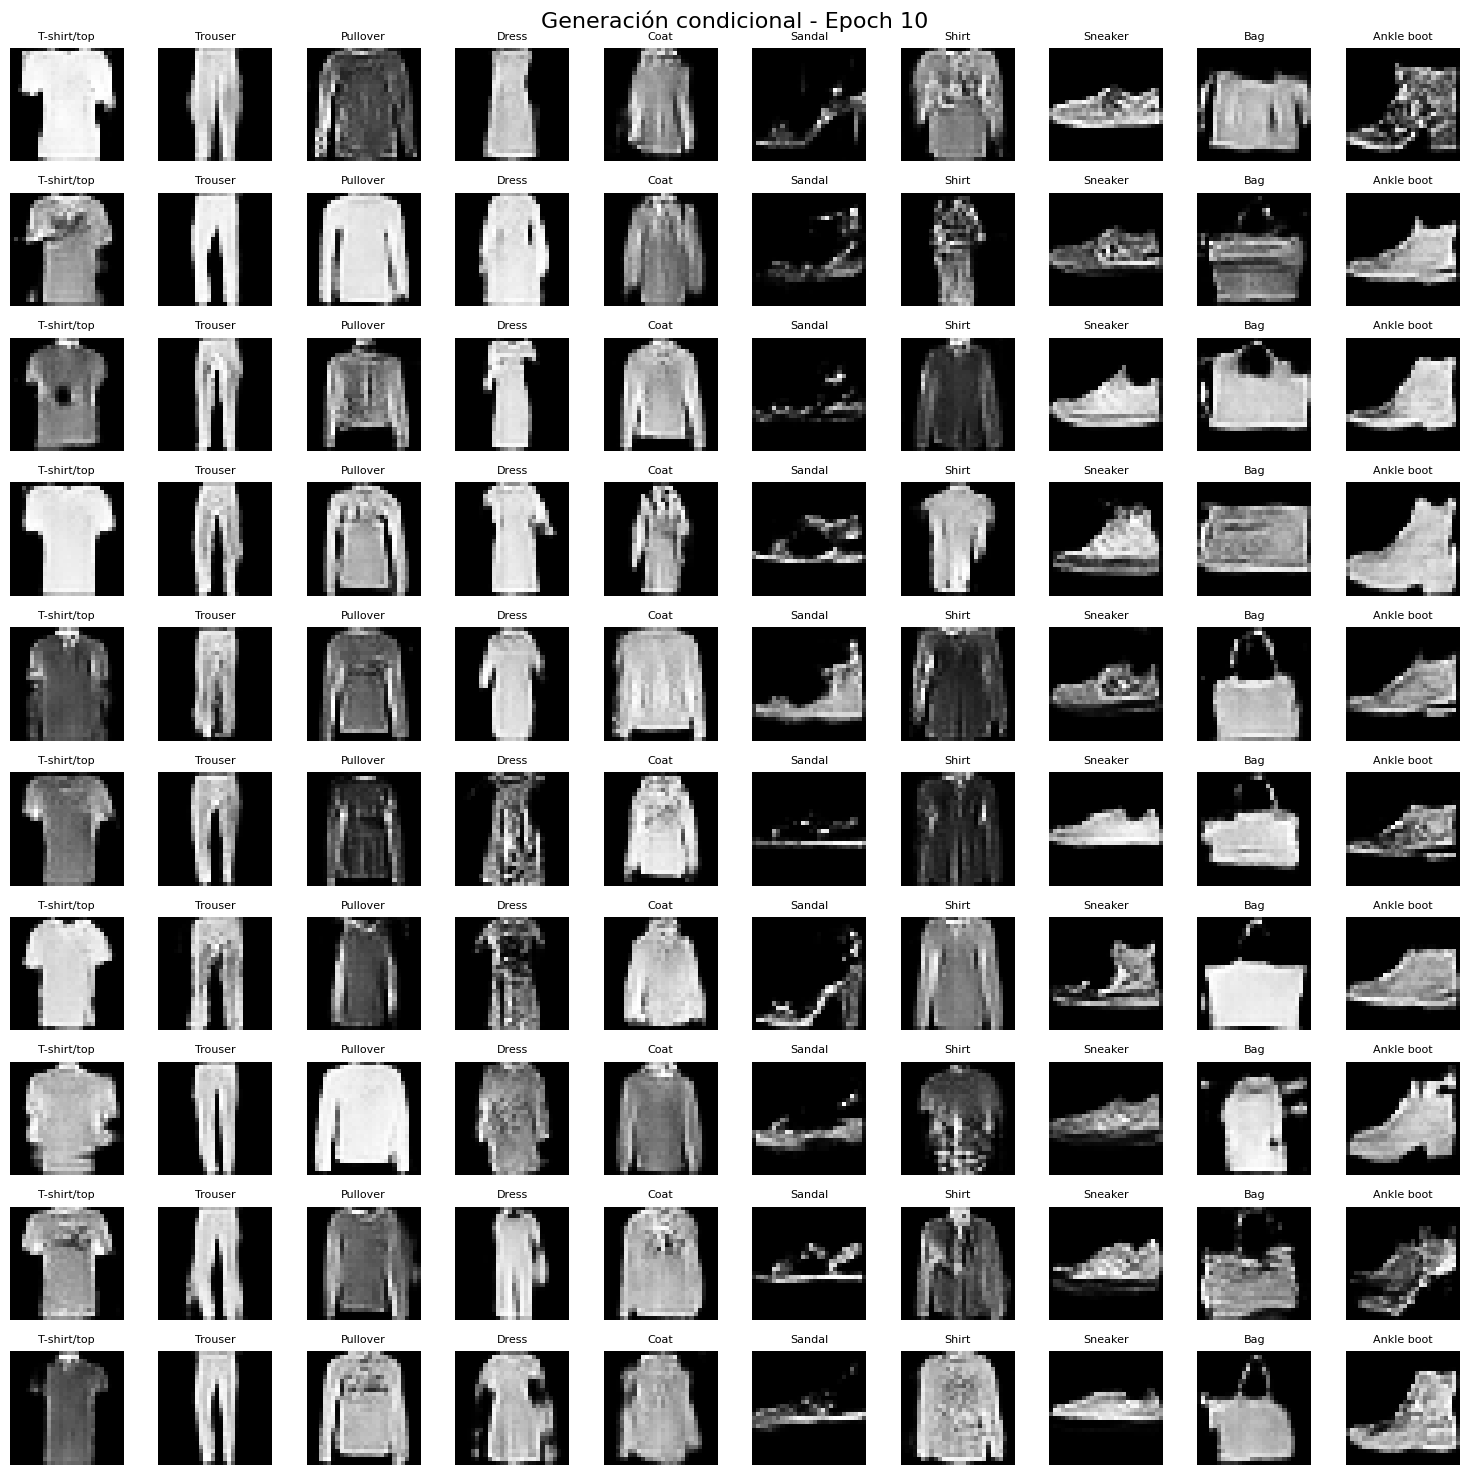

Epoch [11/50] | D Loss: 1.3436 | G Loss: 0.7640
Epoch [12/50] | D Loss: 1.3440 | G Loss: 0.7612
Epoch [13/50] | D Loss: 1.3460 | G Loss: 0.7609
Epoch [14/50] | D Loss: 1.3461 | G Loss: 0.7573
Epoch [15/50] | D Loss: 1.3472 | G Loss: 0.7573


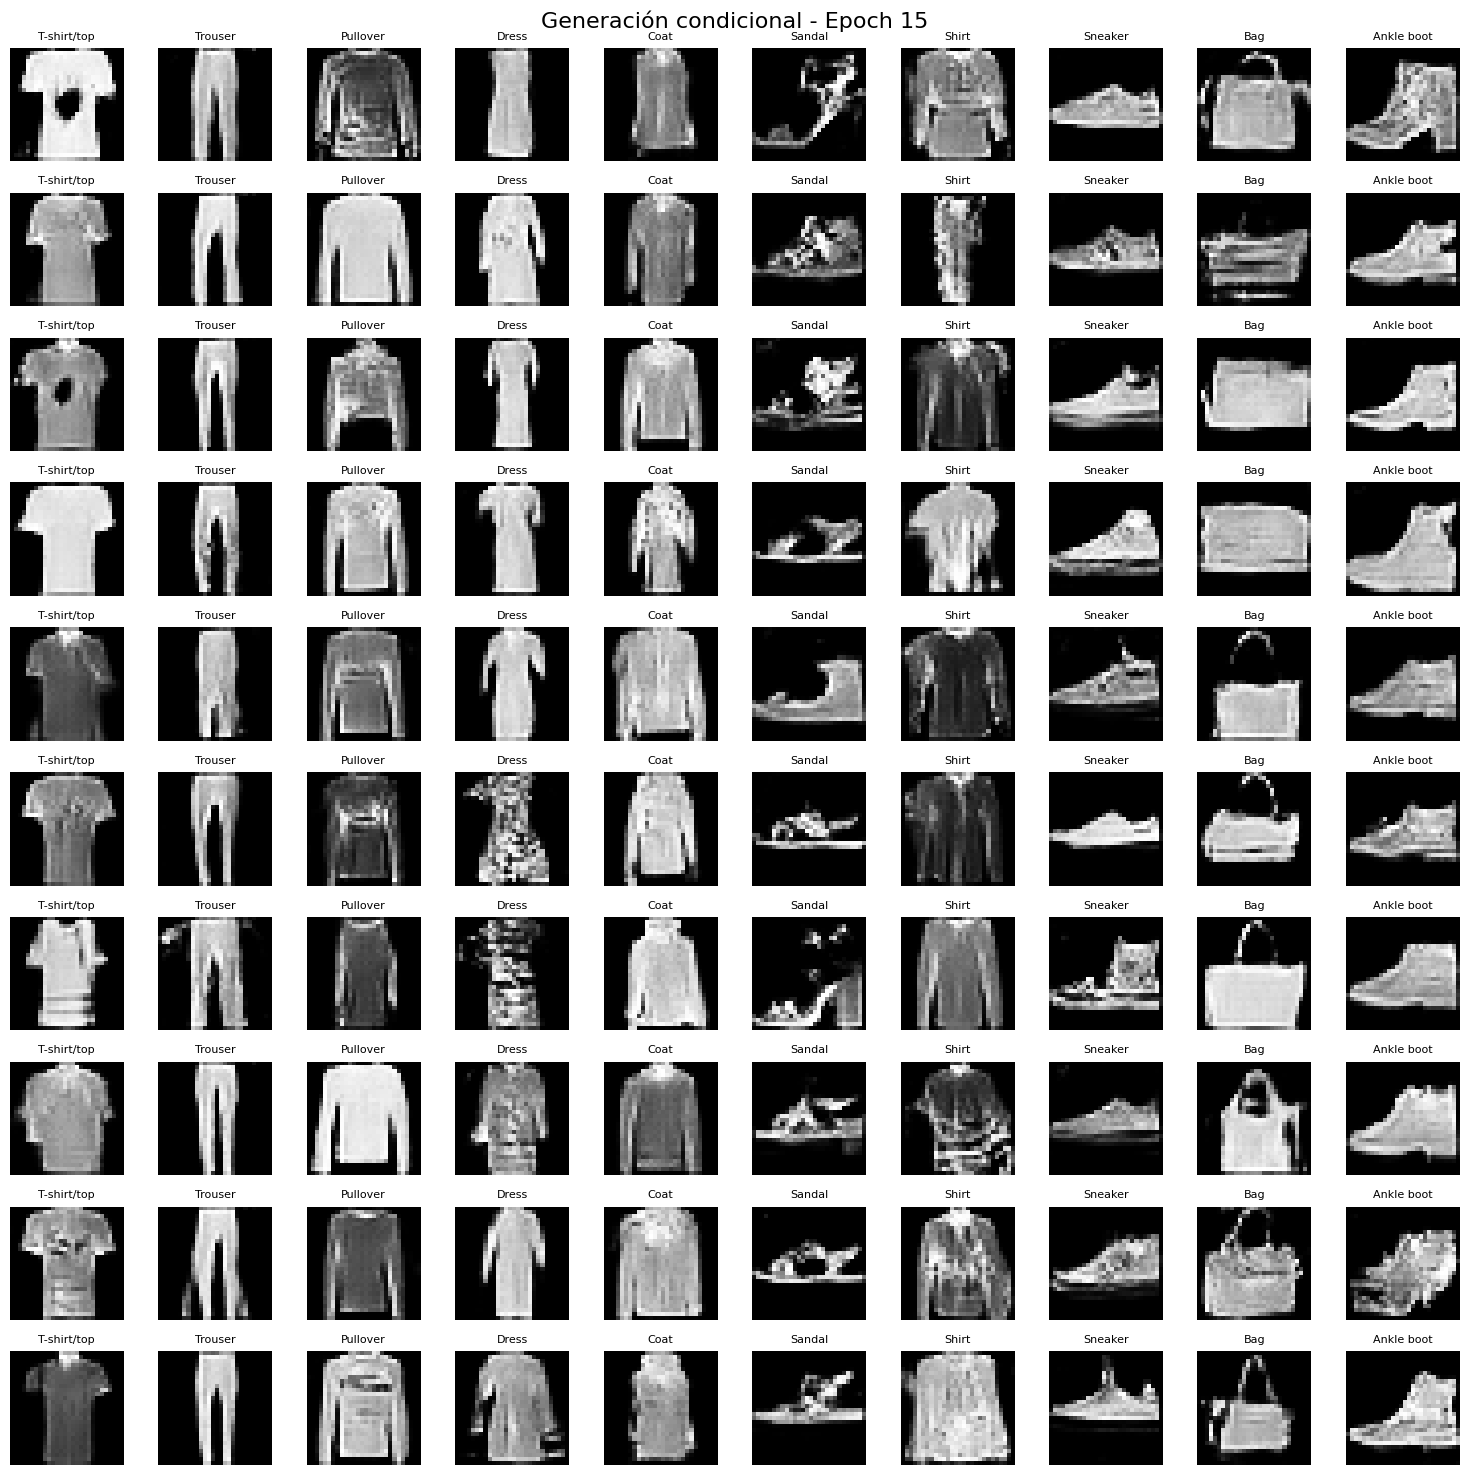

Epoch [16/50] | D Loss: 1.3470 | G Loss: 0.7591
Epoch [17/50] | D Loss: 1.3484 | G Loss: 0.7587
Epoch [18/50] | D Loss: 1.3477 | G Loss: 0.7561
Epoch [19/50] | D Loss: 1.3456 | G Loss: 0.7569
Epoch [20/50] | D Loss: 1.3461 | G Loss: 0.7588


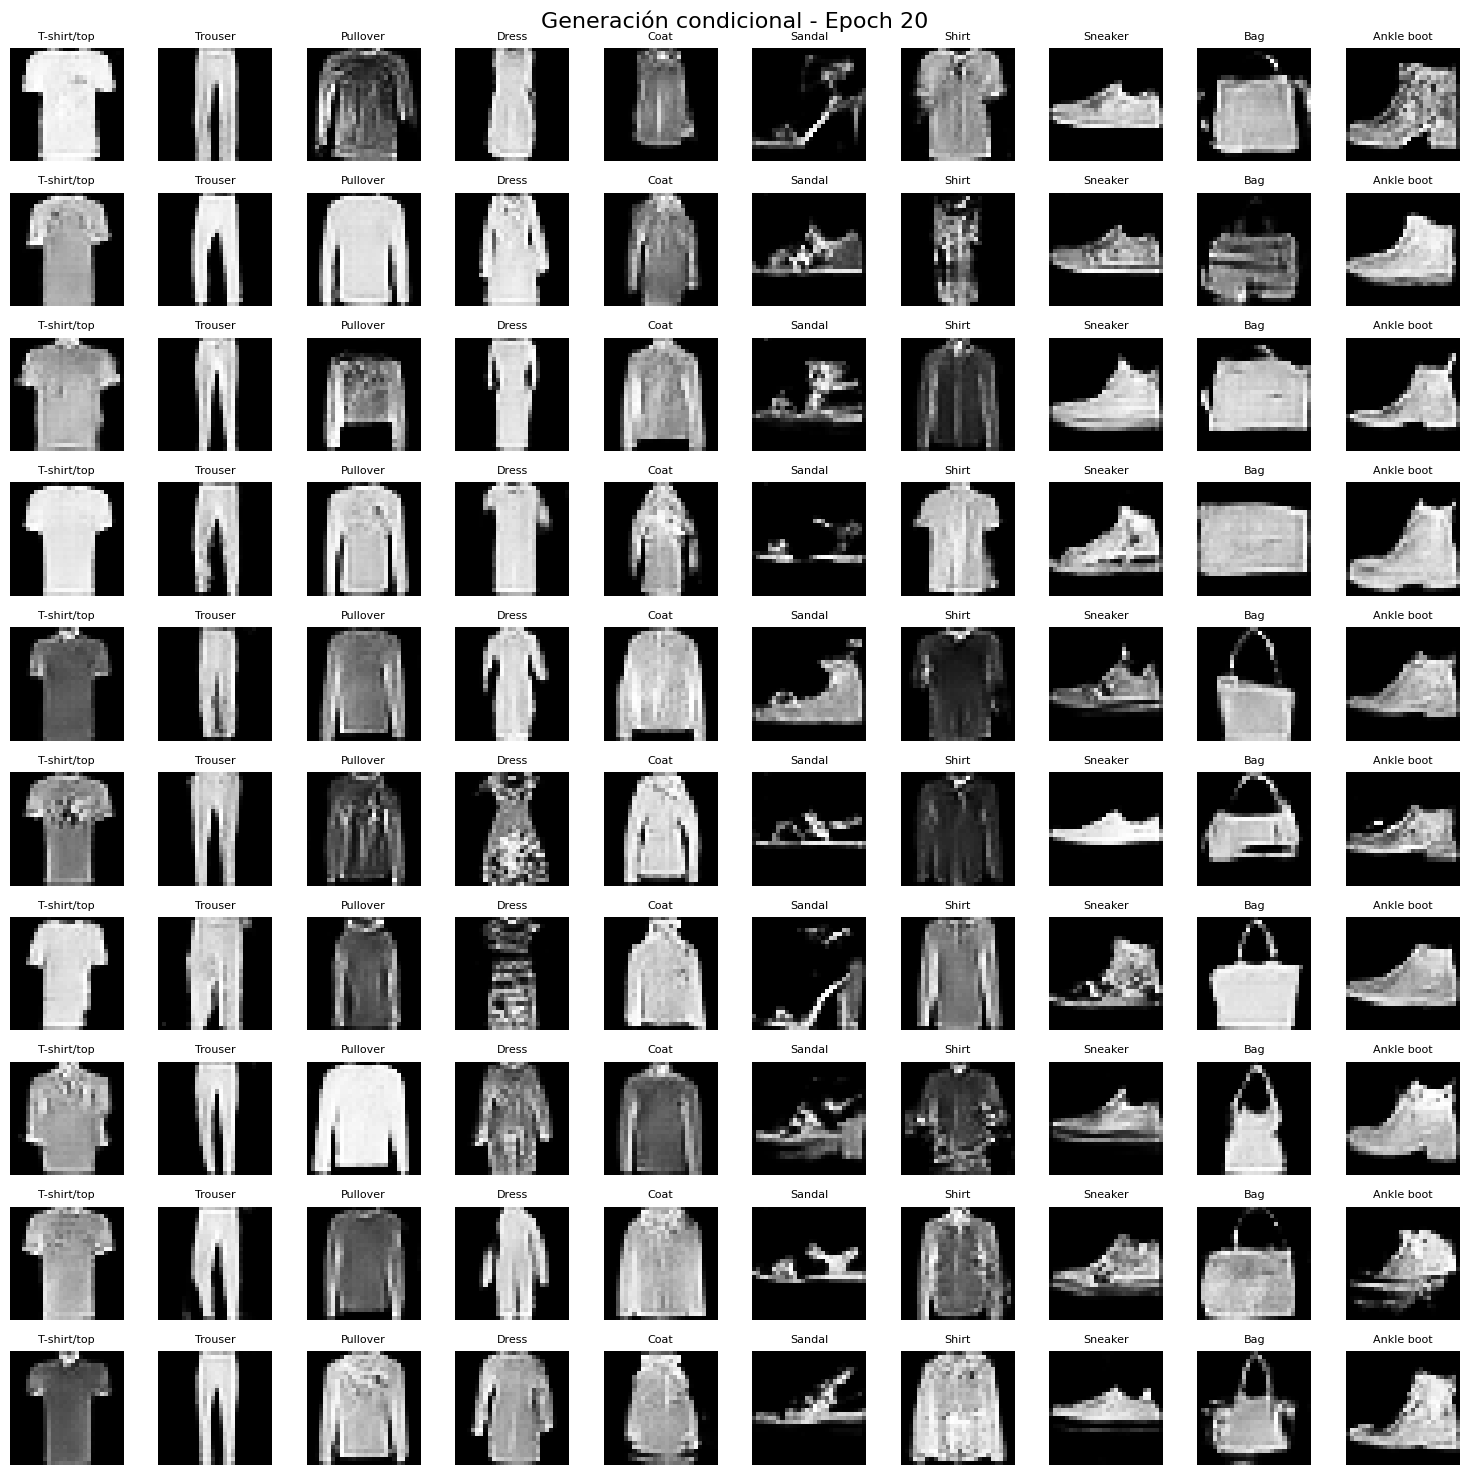

Epoch [21/50] | D Loss: 1.3475 | G Loss: 0.7575
Epoch [22/50] | D Loss: 1.3482 | G Loss: 0.7570
Epoch [23/50] | D Loss: 1.3451 | G Loss: 0.7575
Epoch [24/50] | D Loss: 1.3471 | G Loss: 0.7580
Epoch [25/50] | D Loss: 1.3462 | G Loss: 0.7572


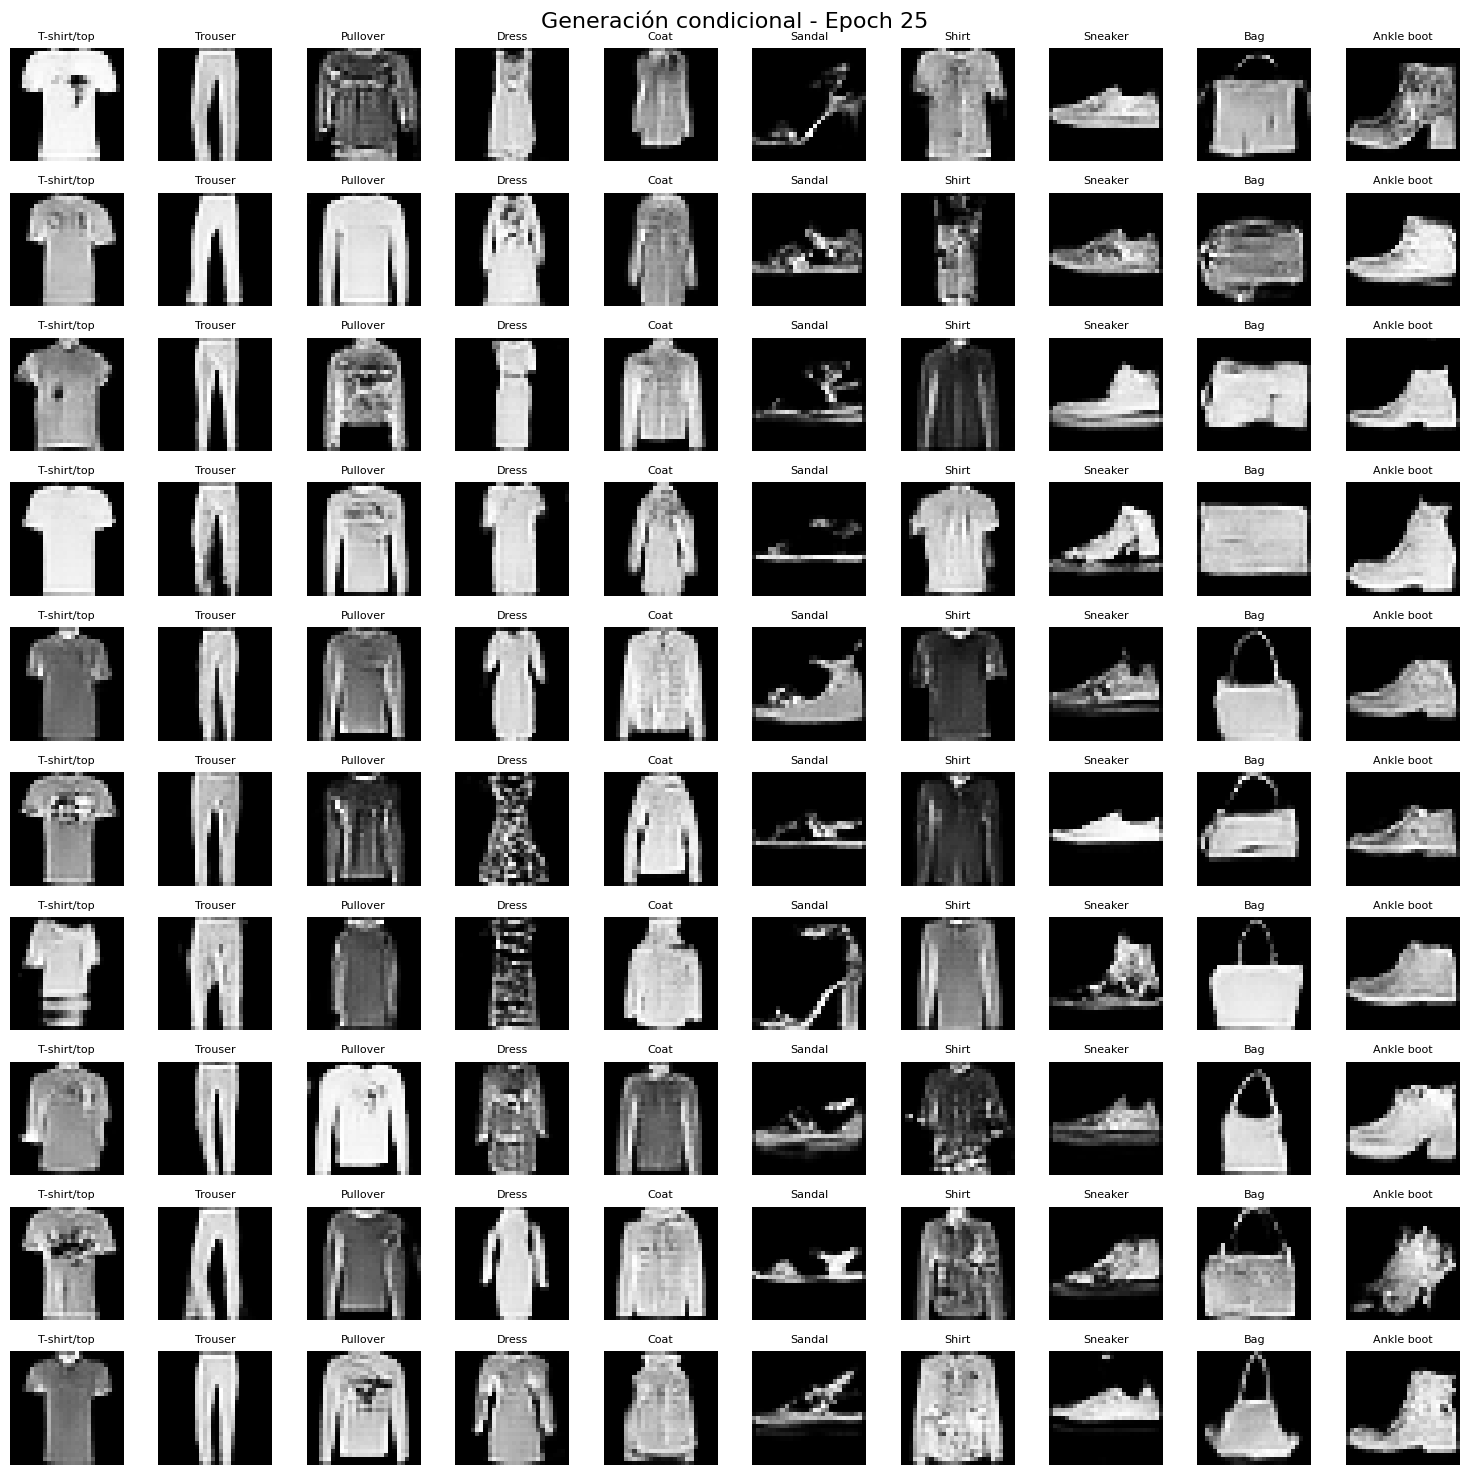

Epoch [26/50] | D Loss: 1.3457 | G Loss: 0.7593
Epoch [27/50] | D Loss: 1.3471 | G Loss: 0.7614
Epoch [28/50] | D Loss: 1.3440 | G Loss: 0.7603
Epoch [29/50] | D Loss: 1.3441 | G Loss: 0.7604
Epoch [30/50] | D Loss: 1.3437 | G Loss: 0.7619


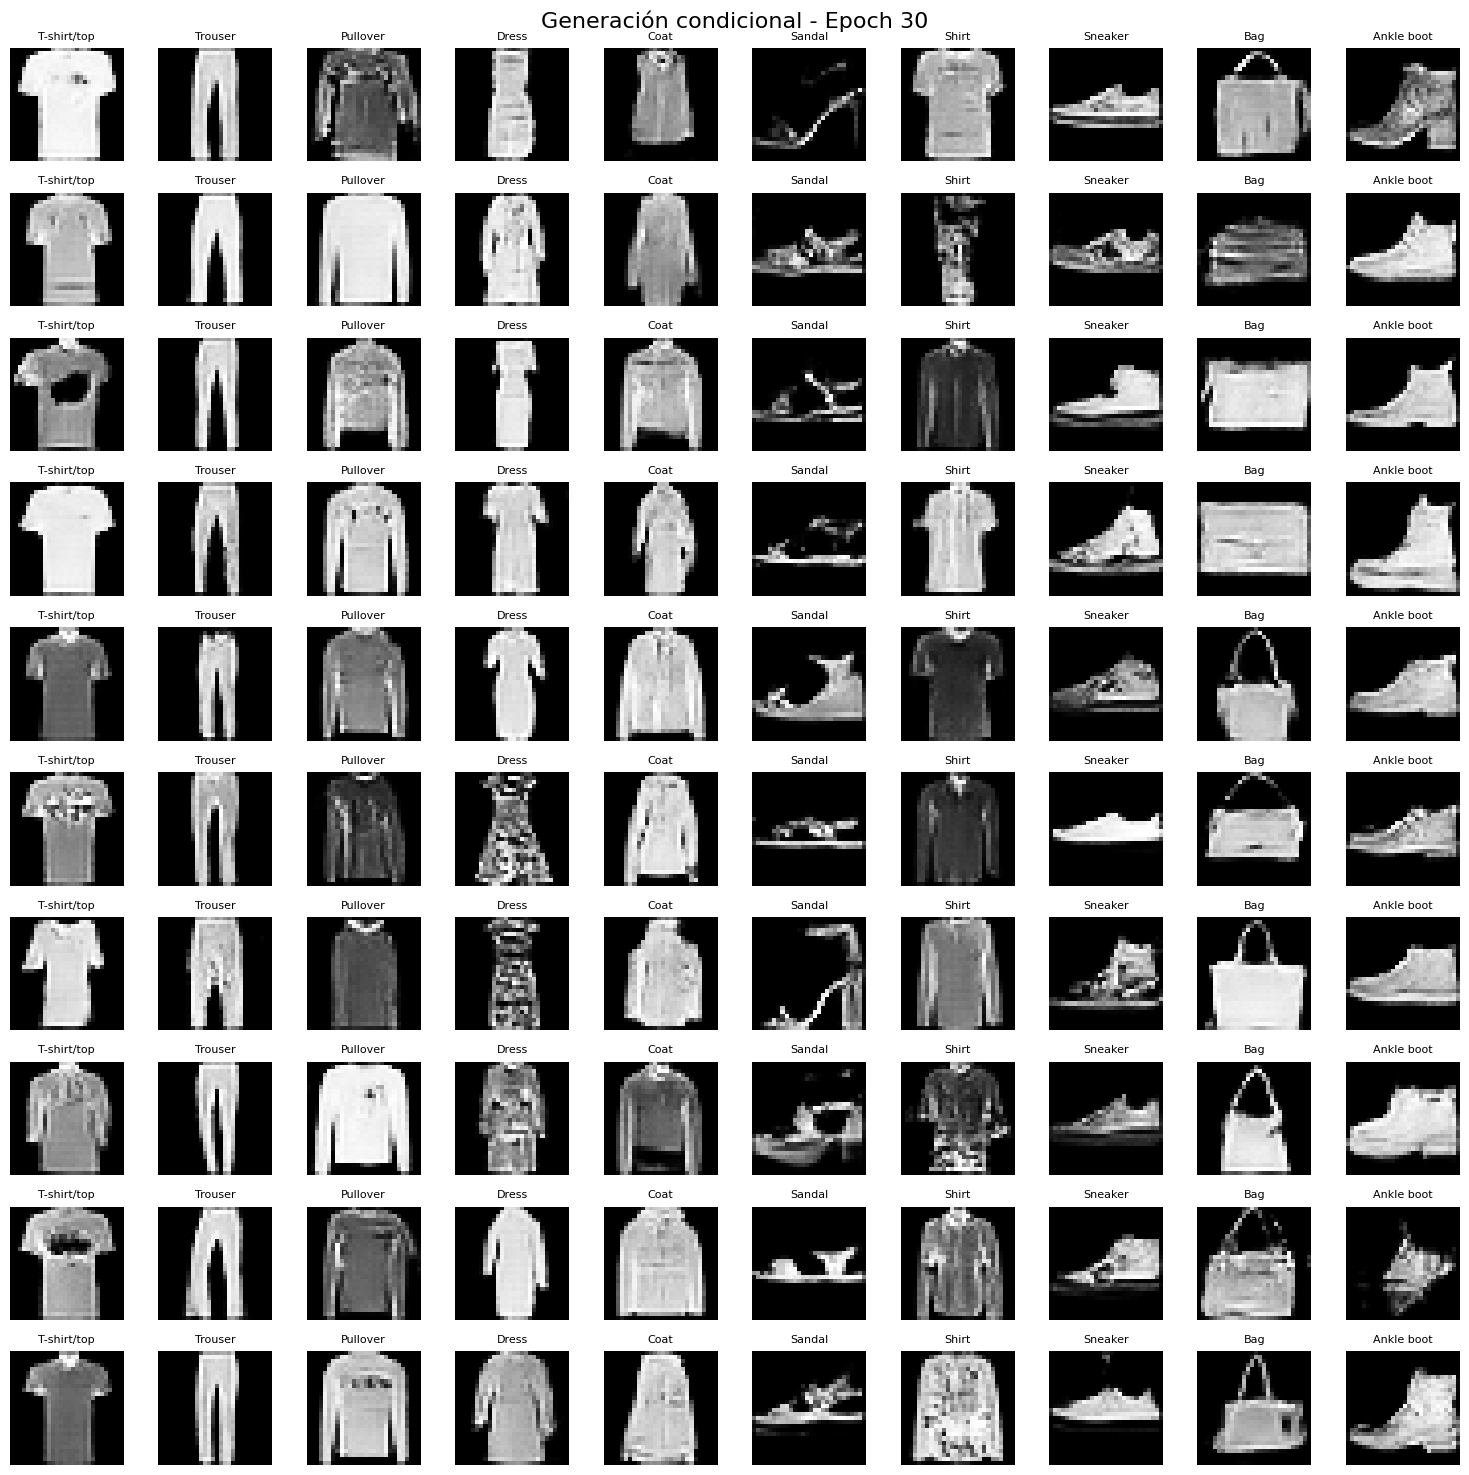

Epoch [31/50] | D Loss: 1.3445 | G Loss: 0.7631
Epoch [32/50] | D Loss: 1.3439 | G Loss: 0.7641
Epoch [33/50] | D Loss: 1.3422 | G Loss: 0.7616
Epoch [34/50] | D Loss: 1.3409 | G Loss: 0.7644
Epoch [35/50] | D Loss: 1.3405 | G Loss: 0.7667


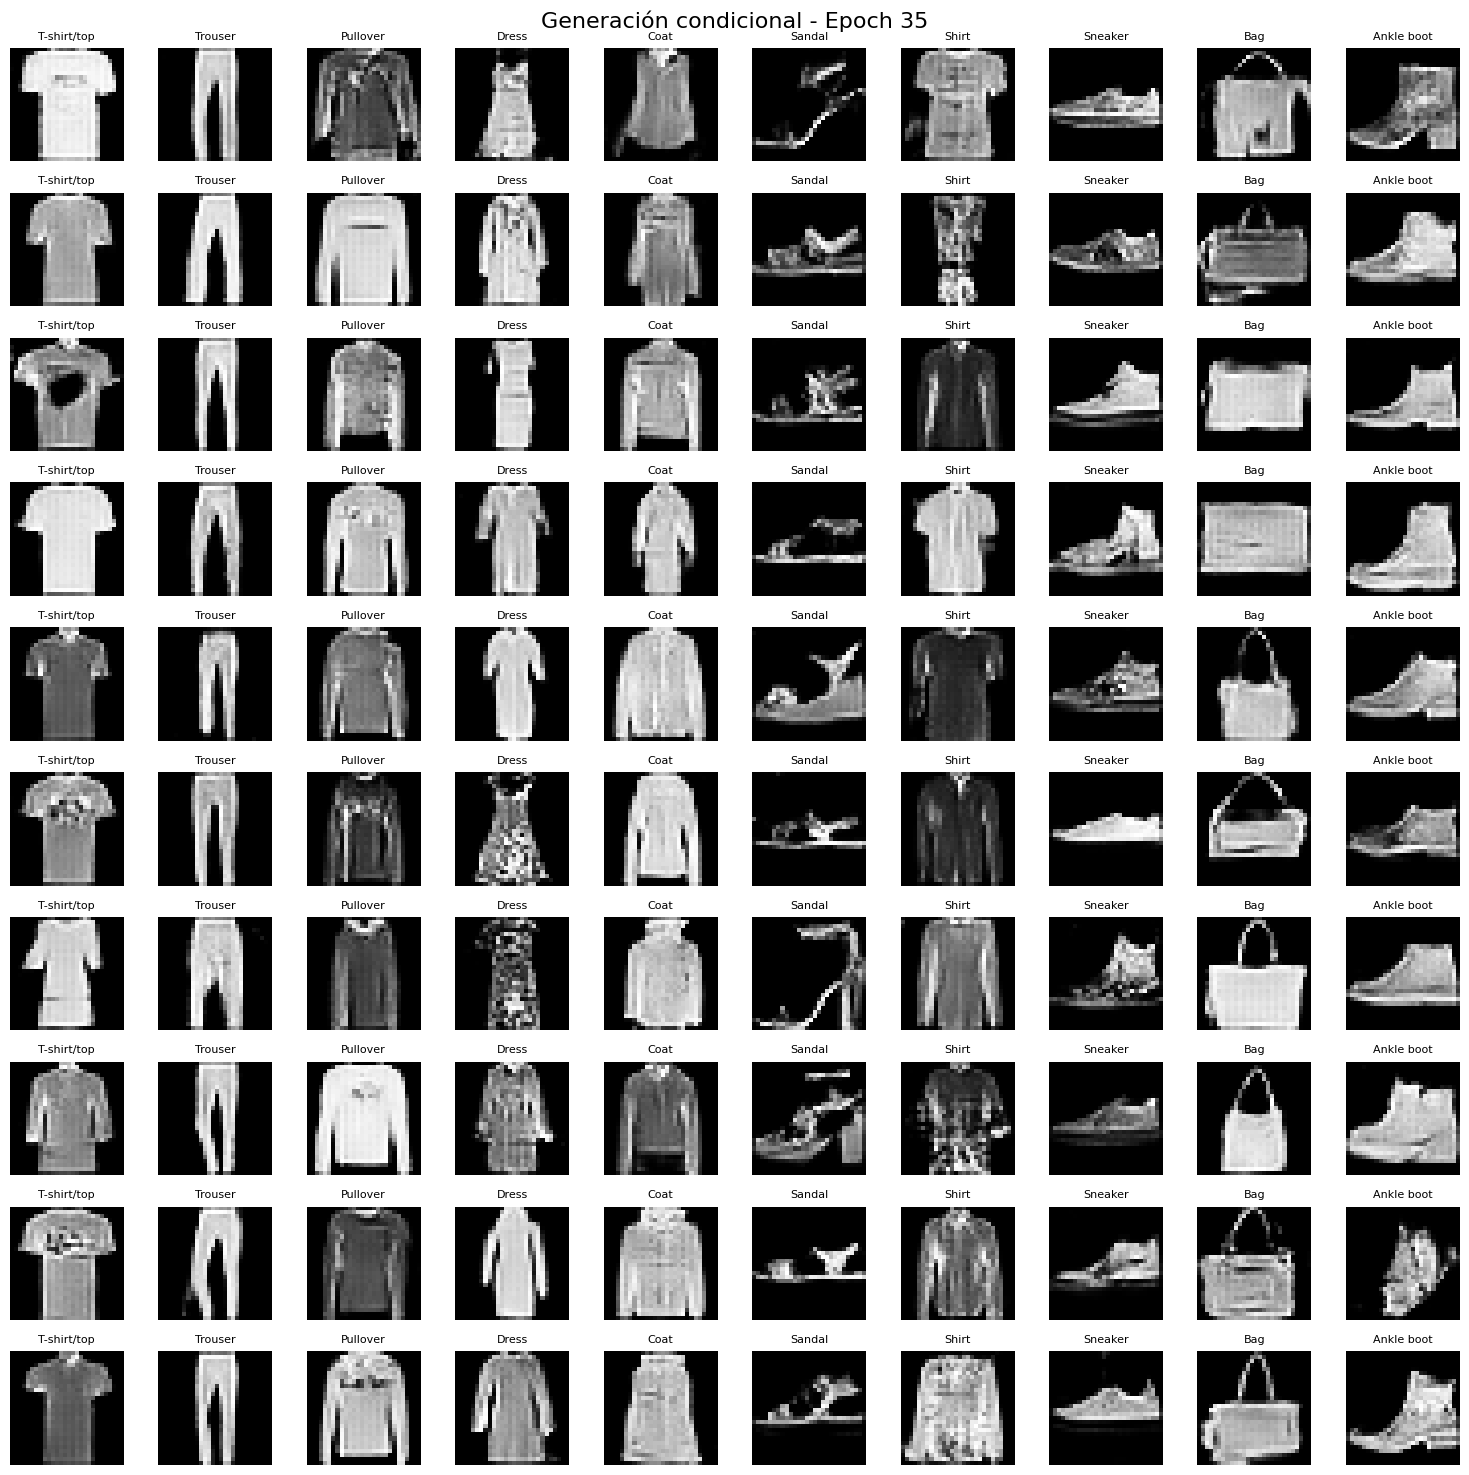

Epoch [36/50] | D Loss: 1.3414 | G Loss: 0.7654
Epoch [37/50] | D Loss: 1.3406 | G Loss: 0.7672
Epoch [38/50] | D Loss: 1.3394 | G Loss: 0.7664
Epoch [39/50] | D Loss: 1.3390 | G Loss: 0.7691
Epoch [40/50] | D Loss: 1.3405 | G Loss: 0.7693


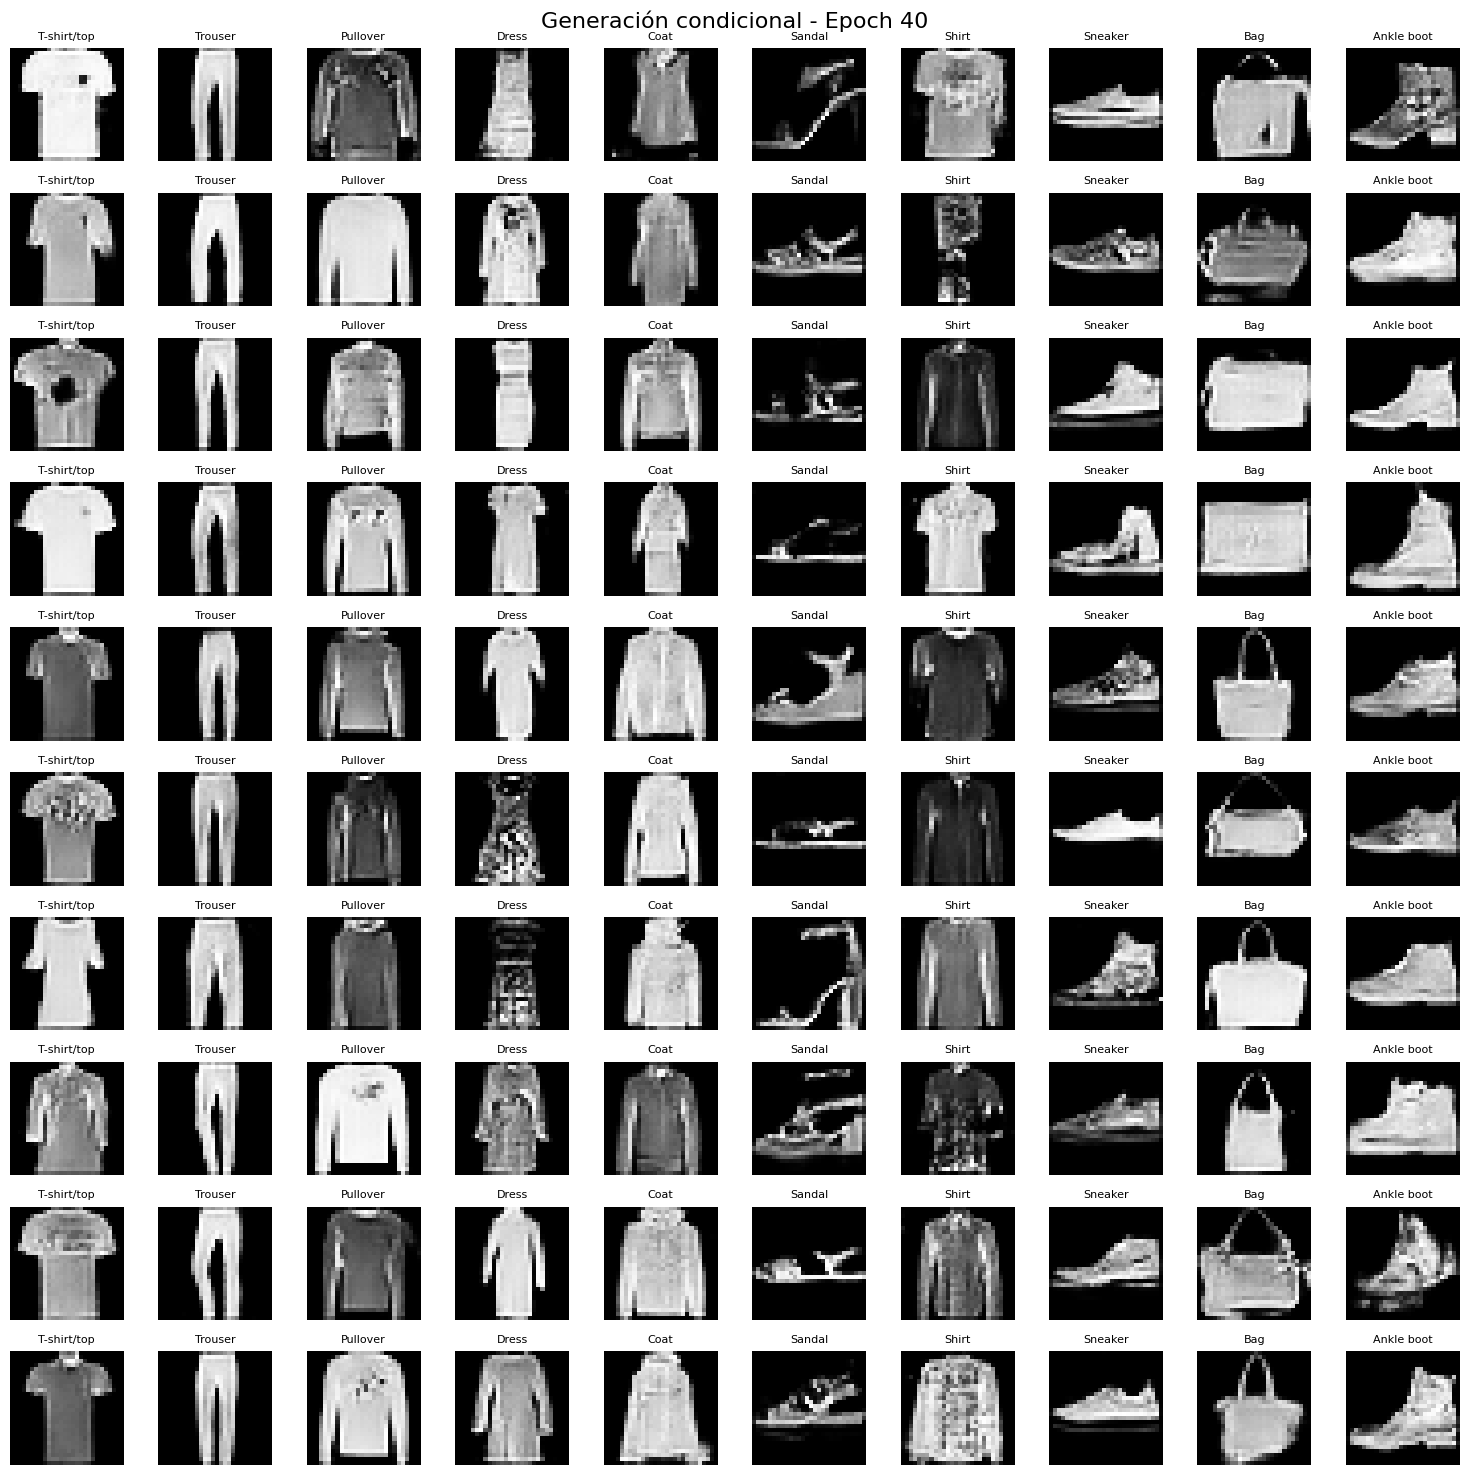

Epoch [41/50] | D Loss: 1.3400 | G Loss: 0.7693
Epoch [42/50] | D Loss: 1.3394 | G Loss: 0.7702
Epoch [43/50] | D Loss: 1.3410 | G Loss: 0.7704
Epoch [44/50] | D Loss: 1.3382 | G Loss: 0.7701
Epoch [45/50] | D Loss: 1.3383 | G Loss: 0.7720


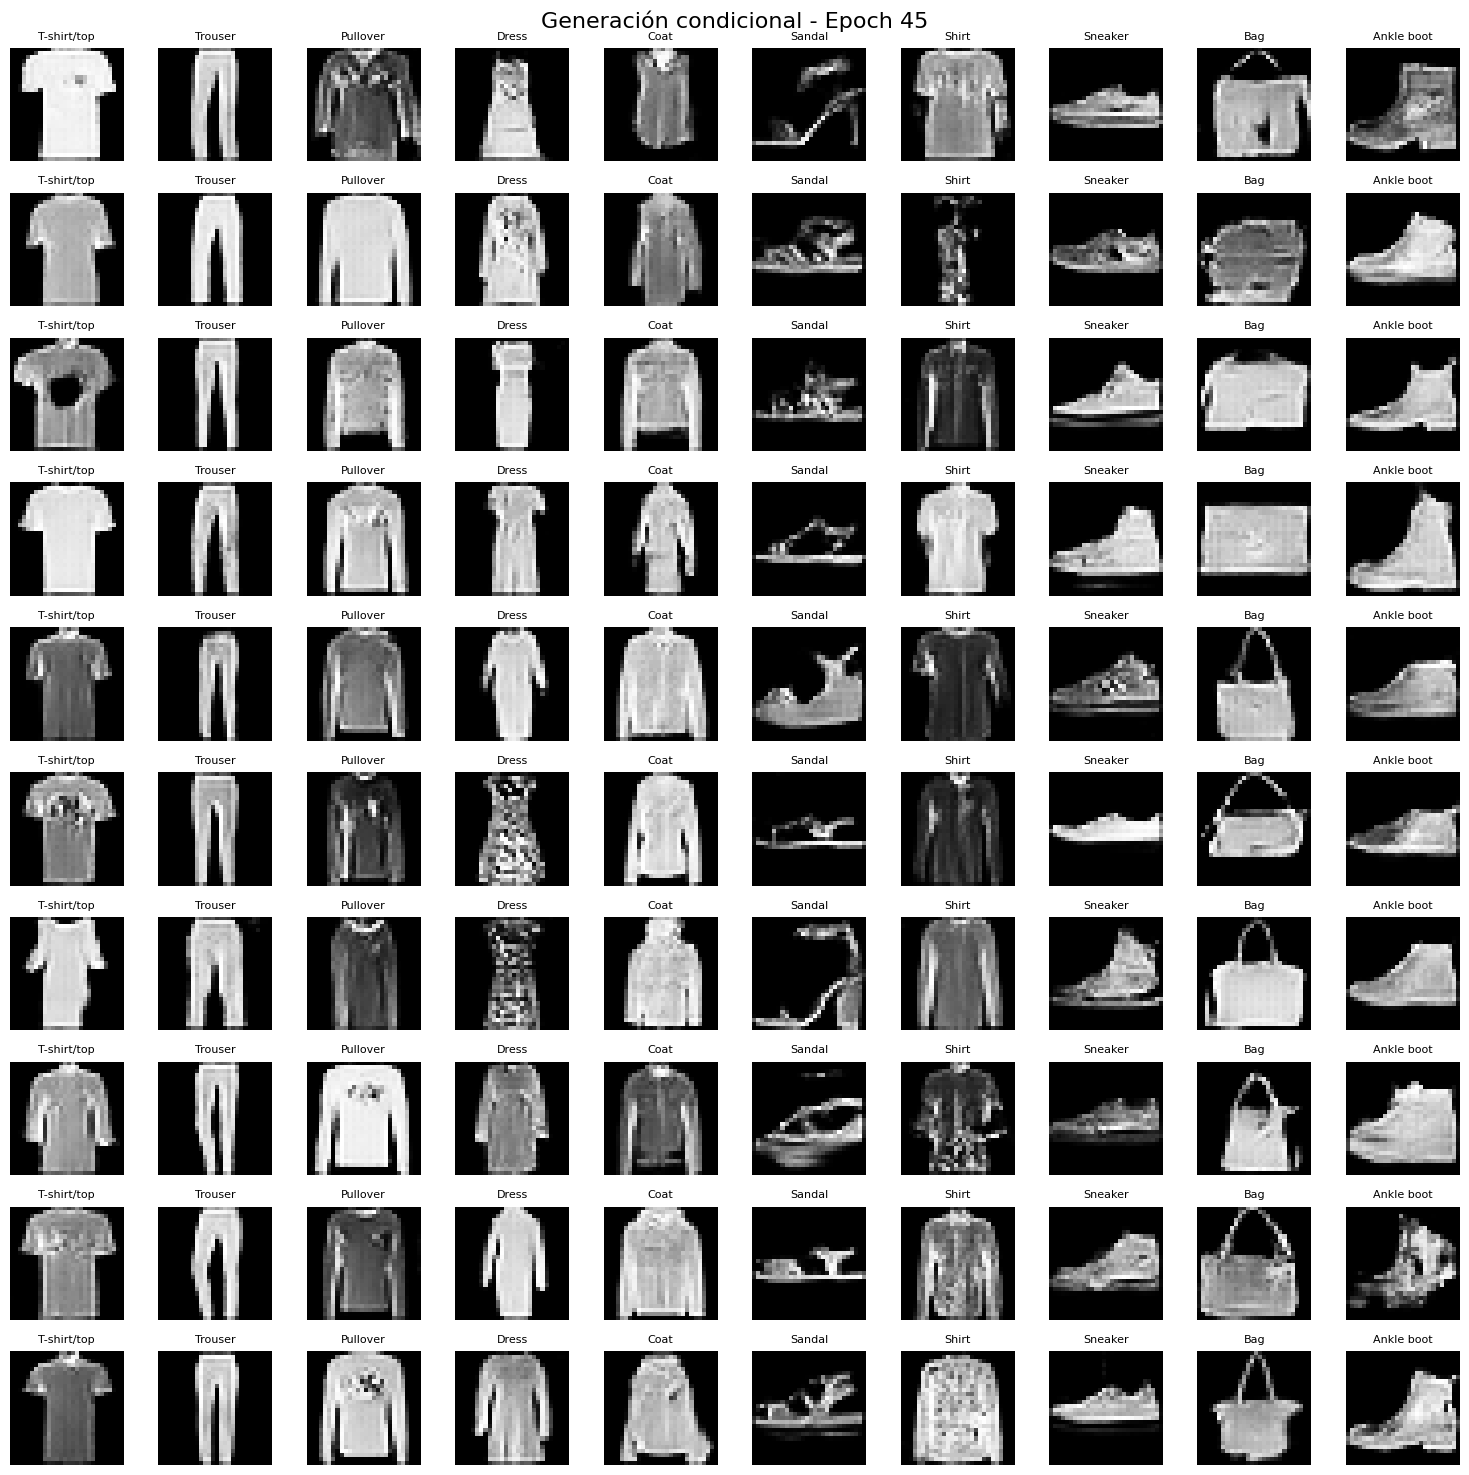

Epoch [46/50] | D Loss: 1.3401 | G Loss: 0.7722
Epoch [47/50] | D Loss: 1.3357 | G Loss: 0.7723
Epoch [48/50] | D Loss: 1.3384 | G Loss: 0.7753
Epoch [49/50] | D Loss: 1.3381 | G Loss: 0.7735
Epoch [50/50] | D Loss: 1.3373 | G Loss: 0.7722


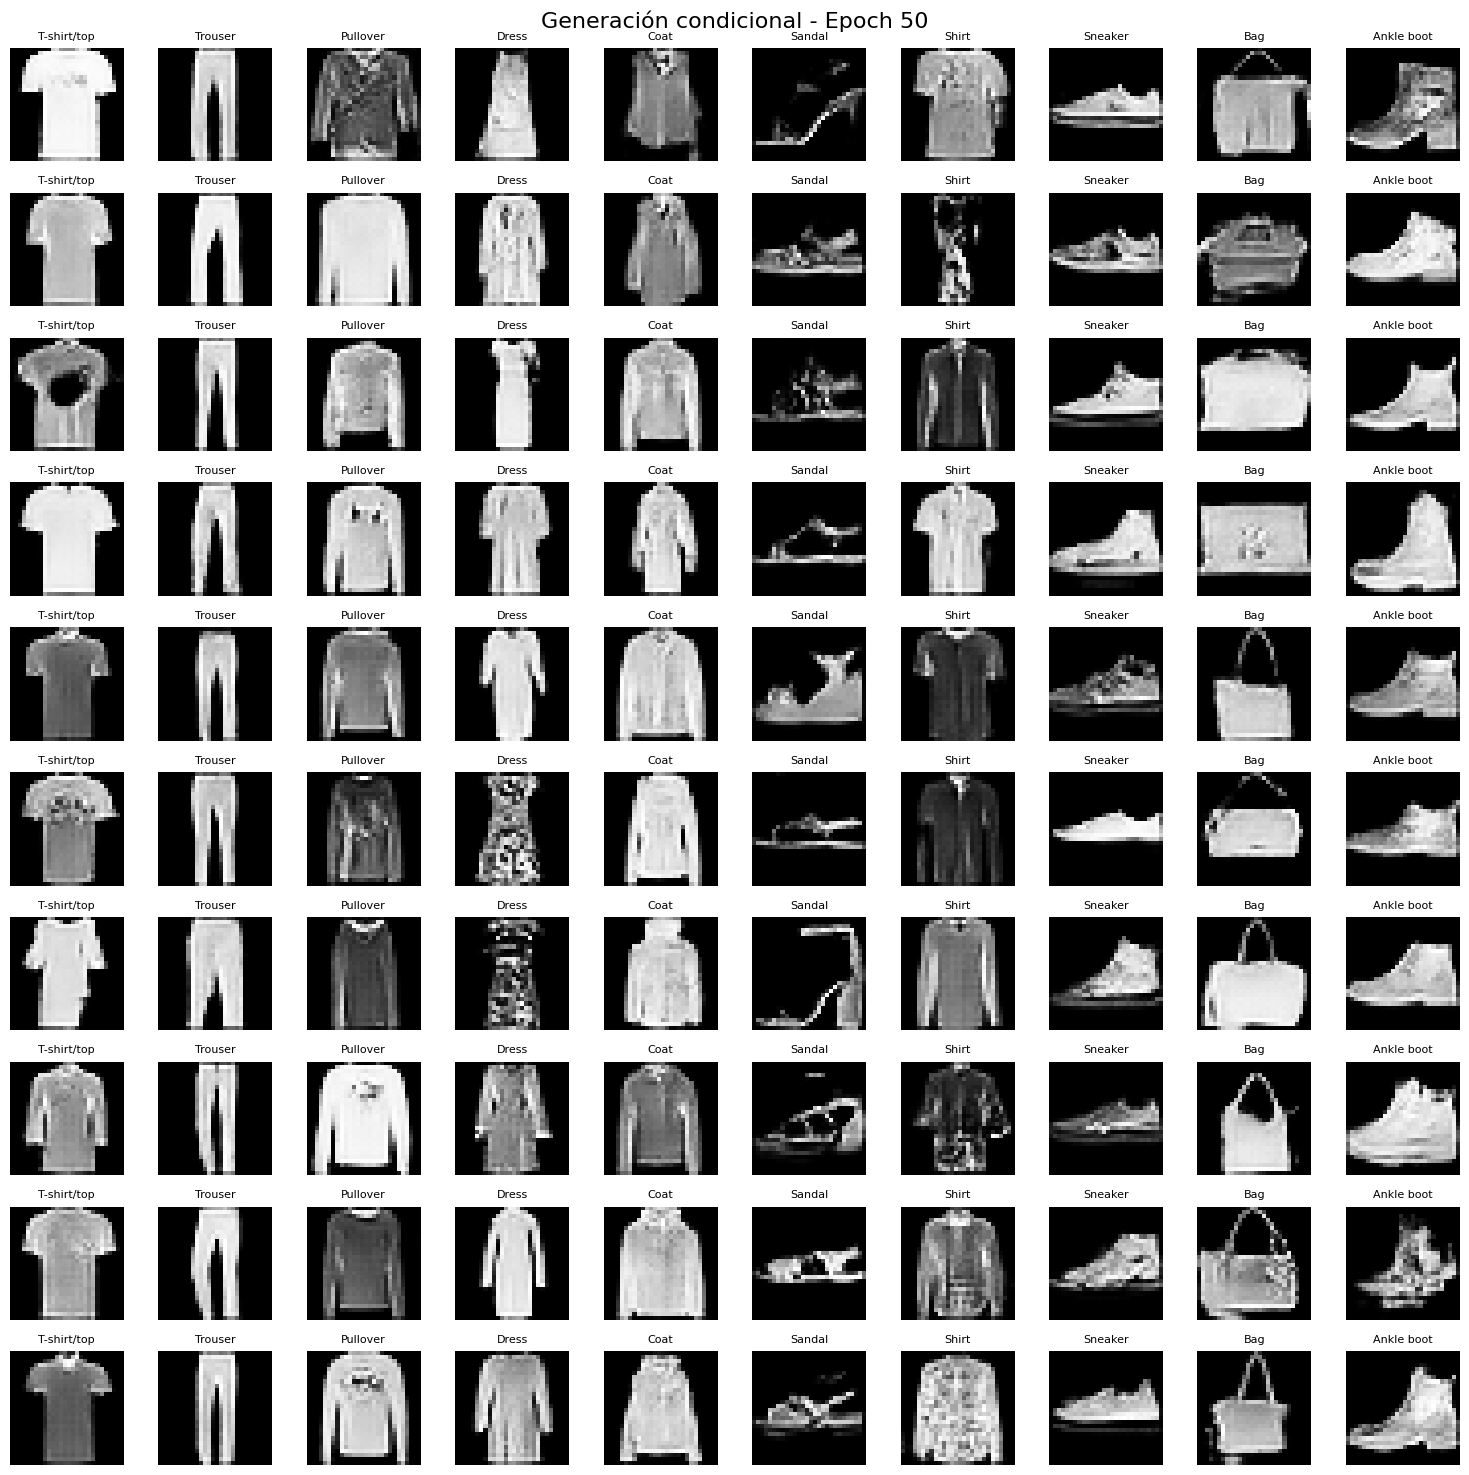

In [13]:
@tf.function
def train_step_conditional(real_images, labels):
    batch_size = tf.shape(real_images)[0]
    labels = tf.expand_dims(labels, axis=-1)
    real_labels_loss = tf.ones((batch_size, 1))
    fake_labels_loss = tf.zeros((batch_size, 1))

    with tf.GradientTape() as tape_cd:
        real_validity = cond_discriminator([real_images, labels], training=True)
        cd_loss_real = cross_entropy(real_labels_loss, real_validity)

        z = tf.random.normal([batch_size, latent_dim])
        fake_labels = tf.random.uniform([batch_size, 1], minval=0, maxval=num_classes, dtype=tf.int32)
        fake_images = cond_generator([z, fake_labels], training=True)
        fake_validity = cond_discriminator([fake_images, fake_labels], training=True)
        cd_loss_fake = cross_entropy(fake_labels_loss, fake_validity)
        cd_loss = cd_loss_real + cd_loss_fake

    grads_cd = tape_cd.gradient(cd_loss, cond_discriminator.trainable_variables)
    optimizer_cD.apply_gradients(zip(grads_cd, cond_discriminator.trainable_variables))

    with tf.GradientTape() as tape_cg:
        z = tf.random.normal([batch_size, latent_dim])
        gen_labels = tf.random.uniform([batch_size, 1], minval=0, maxval=num_classes, dtype=tf.int32)
        gen_images = cond_generator([z, gen_labels], training=True)
        validity = cond_discriminator([gen_images, gen_labels], training=True)
        cg_loss = cross_entropy(real_labels_loss, validity)

    grads_cg = tape_cg.gradient(cg_loss, cond_generator.trainable_variables)
    optimizer_cG.apply_gradients(zip(grads_cg, cond_generator.trainable_variables))

    return cd_loss, cg_loss

def train_conditional_gan():
    for epoch in range(num_epochs_cgan):
        epoch_cd_loss = 0.0
        epoch_cg_loss = 0.0
        num_batches = 0

        for real_imgs, labels in fashion_dataset:
            cd_loss, cg_loss = train_step_conditional(real_imgs, labels)
            epoch_cd_loss += cd_loss
            epoch_cg_loss += cg_loss
            num_batches += 1

        avg_cd_loss = epoch_cd_loss / num_batches
        avg_cg_loss = epoch_cg_loss / num_batches
        cd_losses.append(float(avg_cd_loss))
        cg_losses.append(float(avg_cg_loss))
        print(f'Epoch [{epoch + 1}/{num_epochs_cgan}] | D Loss: {avg_cd_loss:.4f} | G Loss: {avg_cg_loss:.4f}')

        if (epoch + 1) % sample_interval == 0:
            samples = cond_generator([fixed_noise_cgan, fixed_labels], training=False).numpy()
            fig, axes = plt.subplots(10, 10, figsize=(15, 15))
            for idx, ax in enumerate(axes.flat):
                ax.imshow(samples[idx, :, :, 0], cmap='gray')
                ax.set_title(class_names[int(fixed_labels[idx, 0])], fontsize=8)
                ax.axis('off')
            plt.suptitle(f'Generación condicional - Epoch {epoch + 1}', fontsize=16)
            plt.tight_layout()
            plt.show()

train_conditional_gan()

## Evolución de la función de coste

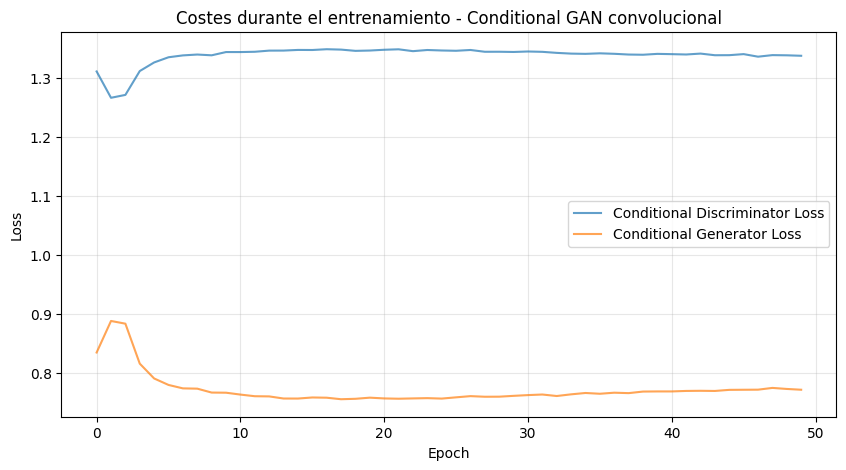

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(cd_losses, label='Conditional Discriminator Loss', alpha=0.7)
plt.plot(cg_losses, label='Conditional Generator Loss', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Costes durante el entrenamiento - Conditional GAN convolucional')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Generación controlada por clase

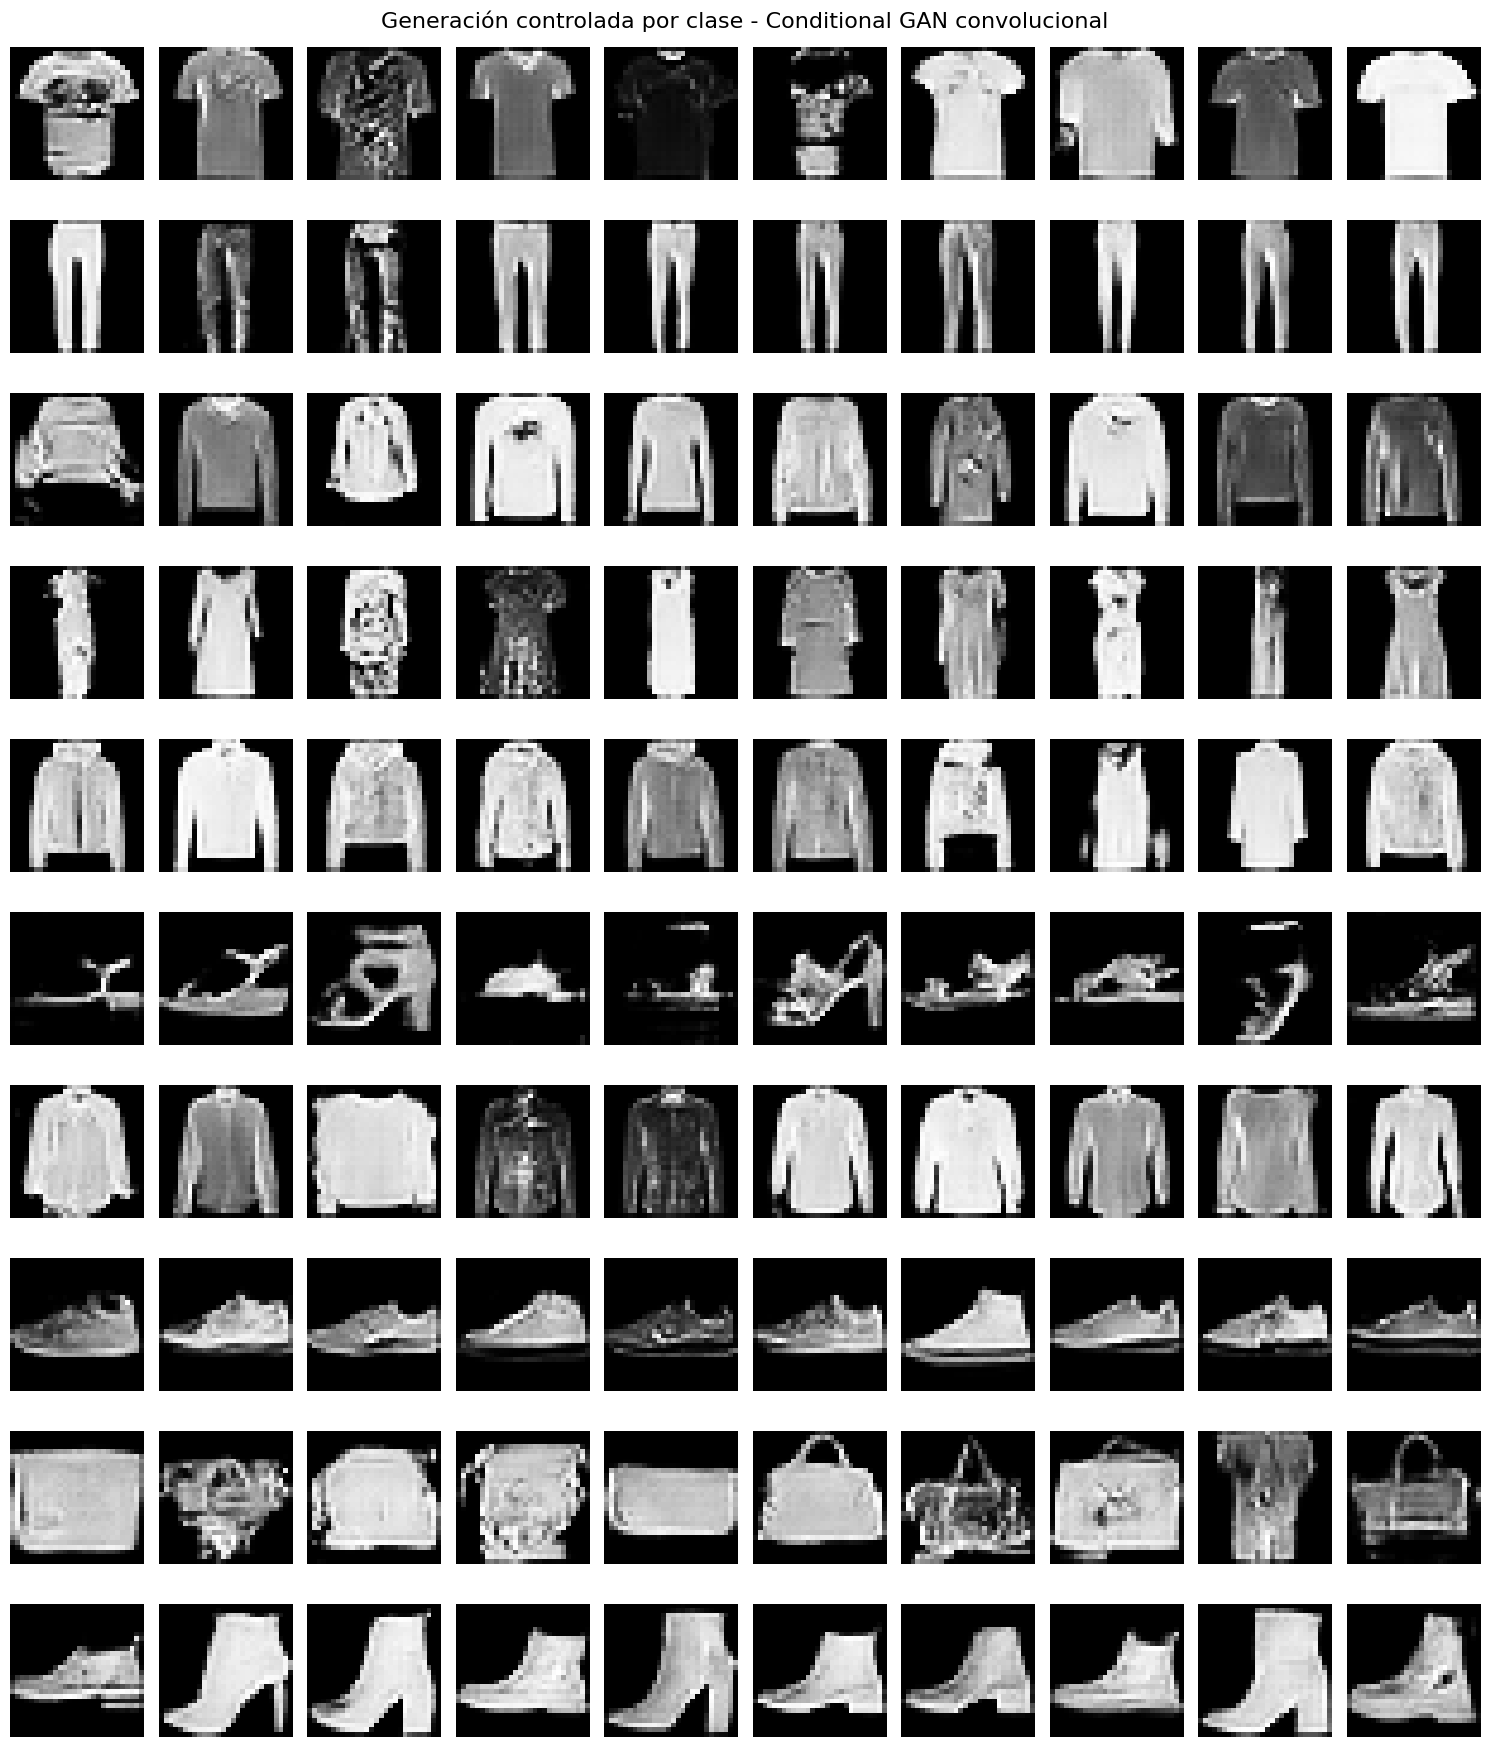

In [15]:
samples_per_class = 10
total_samples = num_classes * samples_per_class
labels_to_generate = tf.constant([[i] for i in range(num_classes) for _ in range(samples_per_class)], dtype=tf.int32)
z = tf.random.normal([total_samples, latent_dim])
generated_samples = cond_generator([z, labels_to_generate], training=False).numpy()

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 18))
for class_idx in range(num_classes):
    for sample_idx in range(samples_per_class):
        idx = class_idx * samples_per_class + sample_idx
        ax = axes[class_idx, sample_idx]
        ax.imshow(generated_samples[idx, :, :, 0], cmap='gray')
        if sample_idx == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=12, rotation=0, ha='right', va='center')
        ax.axis('off')

plt.suptitle('Generación controlada por clase - Conditional GAN convolucional', fontsize=16)
plt.tight_layout()
plt.show()